## *For up-to-date plotting script use plots/combineFiles.ipynb*

In [1]:
import pandas as pd
import numpy as np
from coffea import util
import itertools
import os, sys
import matplotlib.pyplot as plt
import mplhep as hep
import uproot
import hist
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle
hep.style.use("CMS")

sys.path.append('../python/')
from functions import loadCoffeaFile, getLabelMap, getCoffeaFilenames, plotBackgroundEstimate, getHist


## Scale factors and IOV

In [2]:
# IOVs = ['2016APV', '2016', '2016all', '2017', '2018', 'Full']
IOVs = ['2016all']
useOldHTcut = False

lumi = {
    "2016APV": 19800.,
    "2016": 16120., #35920 - 19800
    "2016all": 35920,
    "2017": 41530./10.,
    "2018": 59800./10., #59740./10., #Blinding
    "Full": 46053. # 137190. Blinded
}

t_BR = 0.6741
ttbar_BR = 0.4544 #PDG 2019
ttbar_xs1 = 831.76 * (0.09210) #pb For ttbar mass from 700 to 1000
ttbar_xs2 = 831.76 * (0.02474) #pb For ttbar mass from 1000 to Inf
toptag_sf = 1.0 #0.9 # Now included as a weight in processing
toptag_kf = 1.0 #0.7
qcd_xs = 1370000000.0 #pb From https://cms-gen-dev.cern.ch/xsdb

systematics = [
        'jes',
        'jer',
        'pileup',
        'pdf',
        'q2',
        'btag',
        'toptagsf',
        'toptagxs',
        'lumi',
        'prefiring'
    ]

oldHTstr = ''
if useOldHTcut:
    oldHTstr = '_oldHTcut'
    
# systematics = ['btag']

## make plot image filenames

In [3]:
directories = [
    'images/png/closureTest/2016all',
    'images/png/closureTest/2016APV',
    'images/png/closureTest/2016',
    'images/png/closureTest/2017',
    'images/png/closureTest/2018',
    'images/png/closureTest/Full',
    'images/pdf/closureTest/2016all',
    'images/pdf/closureTest/2016APV',
    'images/pdf/closureTest/2016',
    'images/pdf/closureTest/2017',
    'images/pdf/closureTest/2018',
    'images/pdf/closureTest/Full',
    'images/png/kinematics/2016all',
    'images/png/kinematics/2016APV',
    'images/png/kinematics/2016',
    'images/png/kinematics/2017',
    'images/png/kinematics/2018',
    'images/png/kinematics/Full',
    'images/pdf/kinematics/2016all',
    'images/pdf/kinematics/2016APV',
    'images/pdf/kinematics/2016',
    'images/pdf/kinematics/2017',
    'images/pdf/kinematics/2018',
    'images/pdf/kinematics/Full'
]


for path in directories:
    if not os.path.exists(path):
        os.makedirs(path)

## functions

In [13]:
def make_error_boxes(ax, xdata, ydata, xerror, yerror, facecolor='none',
                     edgecolor='none', alpha=0.5):
    
    # Loop over data points; create box from errors at each point
    errorboxes = [Rectangle((x - xe, y - ye), xe.sum(), ye.sum()) for x, y, xe, ye in zip(xdata, ydata, xerror.T, yerror.T)]

    # Create patch collection with specified colour/alpha
    pc = PatchCollection(errorboxes, facecolor=facecolor, alpha=alpha,
                         edgecolor=edgecolor)

    # Add collection to axes
    ax.add_collection(pc)

    # Plot errorbars
    artists = ax.errorbar(xdata, ydata, xerr=xerror, yerr=yerror,
                          fmt='none', ecolor='k', barsabove=True)

    return artists

def getHist(hname, ds, bkgest, year, sum_axes=[], integrate_axes={}, masspoint=''):
    
    ######################################################################################
    # hname = histogram name (example: 'ttbarmass')                                      #
    # ds = dataset name (example: 'JetHT')                                               #
    # bkgest = boolean, True if bkg estimate applied                                     #
    # year = '2016APV' or '2016' or '2017' or '2018'                                     #
    # sum_axes = names of axes to sum over for scikit-hep/hist histogram                 #
    # integrate_axes = range to integrate over axis (example: {'anacat': [0,1,2,3,4,5]}) #
    ######################################################################################    

    
    # load histograms and get scale factors
    coffeaFiles = getCoffeaFilenames(False, useOldHTcut)
    
    cfiles = []
    sf = []
    bkgest_str = np.where([bkgest], 'weighted', 'unweighted')[0]
    print(coffeaFiles[ds][bkgest_str][year])
    
    if 'QCD' in ds:
        loaded_file = util.load(coffeaFiles[ds][bkgest_str][year])
        sum_axes_dict = {ax:sum for ax in sum_axes}
        histo = loaded_file[hname][integrate_axes][sum_axes_dict]
        histo = histo * (lumi[IOV] * qcd_xs / loaded_file['cutflow']['sumw'])
        return histo
    else:  
        for key, file in coffeaFiles[ds][bkgest_str][year].items():
            if masspoint != '':
                if masspoint in key:
                    loaded_file = util.load(file)
                    sum_axes_dict = {ax:sum for ax in sum_axes}
                    histo = loaded_file[hname][integrate_axes][sum_axes_dict]
                    histo = histo * (lumi[IOV] * 1.0 / loaded_file['cutflow']['sumw'])
                    return histo

            loaded_file = util.load(file)
            cfiles.append(loaded_file)


            if 'TTbar' in ds and '700to1000' in key:
                sf.append(lumi[year] * ttbar_xs1 * toptag_sf**2 * toptag_kf / (loaded_file['cutflow']['sumw']))
            elif 'TTbar' in ds and '1000toInf' in key:
                sf.append(lumi[year] * ttbar_xs2 * toptag_sf**2 * toptag_kf / (loaded_file['cutflow']['sumw']))     
            else:
                sf.append(1.)
        
    # sum or integrate axes for all hists from dataset eras or pt bins
    sum_axes_dict = {ax:sum for ax in sum_axes}
    
    hists = []
    for cfile in cfiles:
        hists.append(cfile[hname][integrate_axes][sum_axes_dict])    
    
    # sum all hists from dataset eras or pt bins
    
    histo = hists[0]*sf[0]
    if len(hists) > 1:
        for i in range(len(hists) - 1): 
            histo = histo + hists[i+1]*sf[i+1]
            
            
    return histo

def getHistNoMassMod(hname, ds, year, sum_axes=[], integrate_axes={}):
    
    ######################################################################################
    # hname = histogram name (example: 'ttbarmass')                                      #
    # ds = dataset name (example: 'JetHT')                                               #
    # bkgest = boolean, True if bkg estimate applied                                     #
    # year = '2016APV' or '2016' or '2017' or '2018'                                     #
    # sum_axes = names of axes to sum over for scikit-hep/hist histogram                 #
    # integrate_axes = range to integrate over axis (example: {'anacat': [0,1,2,3,4,5]}) #
    ######################################################################################    

    
    # load histograms and get scale factors
    coffeaFiles = getCoffeaFilenames(False, useOldHTcut)
    
    cfiles = []
    sf = []
    noMassMod_str = 'noMassMod'
    
    for key, file in coffeaFiles[ds][noMassMod_str][year].items():
            
        loaded_file = util.load(file)
        cfiles.append(loaded_file)
        
        
        if 'TTbar' in ds and '700to1000' in key:
            sf.append(lumi[year] * ttbar_xs1 * toptag_sf**2 * toptag_kf / loaded_file['cutflow']['sumw'])
        elif 'TTbar' in ds and '1000toInf' in key:
            sf.append(lumi[year] * ttbar_xs2 * toptag_sf**2 * toptag_kf / loaded_file['cutflow']['sumw'])  
        else:
            sf.append(1.)
        
    # sum or integrate axes for all hists from dataset eras or pt bins
    sum_axes_dict = {ax:sum for ax in sum_axes}
    
    hists = []
    for cfile in cfiles:
        hists.append(cfile[hname][integrate_axes][sum_axes_dict])    
    
    # sum all hists from dataset eras or pt bins
    histo = hists[0]*sf[0]
    if len(hists) > 1:
        for i in range(len(hists) - 1): 
            histo = histo + hists[i+1]*sf[i+1]
            
            
    return histo

In [5]:
def plotBackgroundEstimate(HistDict, SystUnc, Text='', SaveFileName='', isInclusive=True, category='', signame='', xaxis='', linear=False, Pull=False, SignalPlot=False):
    
    Hbkg = HistDict['ntmj'] + HistDict['ttbar']
    Hbkg_fixed = HistDict['ntmj_fixed'] + HistDict['ttbar']
    
    Ndenom = HistDict['antitag_data'].values() - HistDict['antitag_ttbar'].values()
    
    mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
    # print('mistag weights per bin: ', mistag_data)
    # print('denominators of mistag weights: ', Ndenom)
    # print('number of NTMJ events per bin: ', HistDict['pretag'].values())
    term1 = np.where(HistDict['pretag'].values()>0., 1. / HistDict['pretag'].values(), 0.)
    term2 = np.where( (Ndenom*mistag_data)>0., (np.ones(len(mistag_data))-mistag_data)/(Ndenom*mistag_data), 0. ) 
    mistagErrProp =  HistDict['ntmj_fixed'].values()*np.sqrt( term1 + term2 )# 1 + 2 = mistag error & stat. error of NTMJ
    
    # mmErrProp = (HistDict['ntmj_fixed_noMM'].values() - HistDict['ntmj_fixed'].values())*0.5 # Mass Mod error source
    mmTerm1 = (HistDict['ntmj_fixed_noMM'].values() - HistDict['ntmj_fixed'].values()) # "source" of Mass Mod error
    mmTerm2 = (HistDict['ntmj_fixed_noMM'].values() + HistDict['ntmj_fixed'].values()) / 2.
    mmPercentErr = np.where( mmTerm2>0., mmTerm1/mmTerm2, 0. ) # Calculated percent error of the difference
    mmErrProp = HistDict['ntmj_fixed'].values()*mmPercentErr # Mass Mod error
    
    # print('number of QCD pretag events per bin: ', HistDict['QCDbkgest'].values())
    # print('number of QCD signal events per bin: ', HistDict['QCDsignal'].values())
    qcdTerm1 = (HistDict['QCDbkgest'].values() - HistDict['QCDsignal'].values()) # "source" of QCD closure error
    qcdTerm2 = (HistDict['QCDbkgest'].values() + HistDict['QCDsignal'].values()) / 2.
    qcdPercentErr = np.where((qcdTerm2 > 10**(-4)), qcdTerm1/qcdTerm2, 0.) # Calculated percent error of the difference
    qcdErrProp = HistDict['ntmj_fixed'].values()*qcdPercentErr #QCD closure error
    # qcdErrProp = np.zeros(len(qcdTerm1)) # temporarily turn off QCD ERROR for testing
    
    errNTMJ = np.sqrt(mistagErrProp**2 + mmErrProp**2 + qcdErrProp**2) # +- dN
    print('qcdClosure Percent Difference = ', qcdPercentErr)
    print('Mass Mod Percent Difference = ', mmPercentErr)
    print('mistagErr = ', mistagErrProp)
    print('massmodErr = ', mmErrProp)
    print('qcdclosureErr = ', qcdErrProp)

    errsUpTTbar = SystUnc['plusErrs'] # + dT
    errsDownTTbar = SystUnc['minusErrs'] # - dT

    # print(errsUpTTbar)
    
    errsUp = np.sqrt( errNTMJ**2 + errsUpTTbar**2 ) # + dB
    errsDown = np.sqrt( errNTMJ**2 + errsDownTTbar**2 ) # - dB
    
    height = errsUp + errsDown
    bottom = Hbkg_fixed.values() - errsDown
        
    if isInclusive and SaveFileName != '':
        with open(SaveFileName, 'a') as f:
            print('Obs.  = ',  '%10i'% np.sum(HistDict['data'].values()), ' +- ', '%1i'% np.sqrt(np.sum(HistDict['data'].values())), file=f)
            print('NTMJ  = ',  '%10i'% np.sum(HistDict['ntmj_fixed'].values()), ' +- ', np.sqrt(np.sum(np.where(errNTMJ>0,errNTMJ**2,0))), file=f)
            print('TTbar = ',  '%10i'% np.sum(HistDict['ttbar'].values()), ' + ', np.sqrt(np.sum(np.where(errsUpTTbar>0,errsUpTTbar**2,0))), ' - ', np.sqrt(np.sum(np.where(errsDownTTbar>0,errsDownTTbar**2,0))), file=f)
    elif not isInclusive and SaveFileName != '':
        with open(SaveFileName, 'a') as f:
            print(category+'\n===================================================', file=f)
            print('Obs.  = ',  '%10i'% np.sum(HistDict['data'].values()), ' +- ', '%1i'% np.sqrt(np.sum(HistDict['data'].values())), file=f)
            print('NTMJ  = ',  '%10i'% np.sum(HistDict['ntmj_fixed'].values()), ' +- ', np.sqrt(np.sum(np.where(errNTMJ>0,errNTMJ**2,0))), file=f)
            print('TTbar = ',  '%10i'% np.sum(HistDict['ttbar'].values()), ' + ', np.sqrt(np.sum(np.where(errsUpTTbar>0,errsUpTTbar**2,0))), ' - ', np.sqrt(np.sum(np.where(errsDownTTbar>0,errsDownTTbar**2,0))), file=f)
            print('\n', file=f)
    
    
#     centers = (edges[:-1] + edges[1:]) / 2
    
    if 'ttbarmass' in xaxis:
        edges = HistDict['ntmj_fixed'].axes['ttbarmass'].edges
    else:
        edges = HistDict['ntmj_fixed'].axes[xaxis].edges
    
    fig, (ax1, ax2) = plt.subplots(nrows=2, height_ratios=[3, 1])
    
    if '2016' in HistDict['IOV']:
        Year = '2016'
    else:
        Year = HistDict['IOV']

    if HistDict['IOV'] == 'Full':
        if linear:
            hep.cms.label(Text, data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), loc=0, fontsize=15, ax=ax1)
        else:
            hep.cms.label('', data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), loc=2, fontsize=20, ax=ax1)
            hep.cms.text(Text, loc=2, fontsize=20, ax=ax1)
    else:
        if linear:
            hep.cms.label(Text, data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), year=Year, loc=0, fontsize=15, ax=ax1)
        else:
            hep.cms.label('', data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), year=Year, loc=2, fontsize=20, ax=ax1)
            hep.cms.text(Text, loc=2, fontsize=20, ax=ax1)
            
    
    S = hist.Stack(HistDict['ttbar'], HistDict['ntmj_fixed'])
    S.plot(ax=ax1, stack=True, histtype="fill", color=['xkcd:deep red', 'xkcd:pale gold'], label=['TTbar', 'NTMJ'])
    hep.histplot(HistDict['data'],  ax=ax1, histtype='errorbar', color='black', label='Data')  

    
    
    ax1.bar(x = edges[:-1],
           height=height,
           bottom=bottom,
           width = np.diff(edges), align='edge', hatch='///', edgecolor='gray',
           linewidth=0, facecolor='none', alpha=0.8,
           zorder=10, label='Unc.')

    
    print('TTbar Unc Up:', errsUpTTbar)
    print('TTbar Unc Down:', errsDownTTbar)
    print('NTMJ Up or Down:', errNTMJ)
    print('Error Up = ', errsUp)
    print('Error Down = ', errsDown)
    print('Height of error bar = ', height)
    
    # print()
    
    if SignalPlot:
        Signal = {
            'RSGluon' : r'RS$_{KK}$ Gluon',
            'ZPrime1' : r'Z ` $1\%$',
            'ZPrime10': r'Z ` $10\%$',
            'ZPrime30': r'Z ` $30\%$',
            'ZPrimeDM': r'Z ` DM'
        }
        hep.histplot(HistDict['sig1'], ax=ax1, histtype='step', label=Signal[signame]+' 1 TeV')
        hep.histplot(HistDict['sig4'], ax=ax1, histtype='step', ls='--', lw=3, label=Signal[signame]+' 4 TeV')
        
            
    if Pull != True:
        ratio_plot =  HistDict['data'] / Hbkg_fixed.values()
        AvgUnc = 0.5*(errsUp + errsDown)
        ratioUnc = ratio_plot*AvgUnc/Hbkg_fixed.values()   #1 / errs
        ratioUncStat = ratio_plot*np.sqrt( 1./(Hbkg_fixed.values()*ratio_plot.values()) + 1./(Hbkg_fixed.values()) )
#         ratioUncStat = 1./Hbkg_fixed.values()

        ax2.bar(x = edges[:-1],
               height=(2.*ratioUnc.values()),
               bottom=(np.ones_like(ratio_plot.values()) - ratioUnc.values()),
               width = np.diff(edges), align='edge', edgecolor='black',
               linewidth=0, facecolor='red', alpha=0.3,
               zorder=10, label='Syst. Unc.')
        
        ax2.bar(x = edges[:-1],
               height=(2.*ratioUncStat.values()),
               bottom=(np.ones_like(ratio_plot.values()) - ratioUncStat.values()),
               width = np.diff(edges), align='edge', hatch='\\\\', edgecolor='black',
               linewidth=0, facecolor='blue', alpha=0.3,
               zorder=10, label='Stat. Unc.')
        
        hep.histplot(ratio_plot, ax=ax2, histtype='errorbar', color='black')
        
        legend2 = plt.legend(bbox_to_anchor =(0.1,-0.85), loc='lower center')
        ax2.set_ylim(0,2)
        ax2.axhline(1, color='black', ls='--')
        ax2.set_ylabel('Data/Bkg')
        
    elif Pull == True:
        
        DminusB = (HistDict['data'] + -1*Hbkg_fixed)
        pull_plot = DminusB / np.sqrt( HistDict['data'].values() + np.where(height>0.,height**2,0.) ) 
        pull_plot_arr = np.where(HistDict['data'].values()>0., pull_plot.values(), 0.)
        
        if np.all(np.abs(pull_plot_arr) < 2.): # check to see if pulls are below 2 sigma
            hist.plot.plot_pull_array(pull_plot, pull_plot_arr, ax=ax2, bar_kwargs={'color':'steelblue'}, pp_kwargs={'alpha':0.5})  
            ax2.set_ylim(-2.5,2.5)
            ax2.set_yticks([-2,-1,0,1,2])
        else:
            print('Pull:', pull_plot_arr)
            hist.plot.plot_pull_array(pull_plot, pull_plot_arr, ax=ax2, bar_kwargs={'color':'lightcoral'}, pp_kwargs={'alpha':0.5})  
            ax2.set_ylim(-3.5,3.5)
            ax2.set_yticks([-3,-2,-1,0,1,2,3])
        ax2.axhline(0, color='black', ls='--')
        ax2.set_ylabel(r'(D-B)/$\sigma_{tot.}$')
            

    ax1.legend(fontsize='xx-small', loc=1)
    ax1.set_yscale('symlog')
    ax1.set_ylabel('Events')
    ax1.set_xlabel('')
    ax1.set_ylim(0, 1e5)
    if useOldHTcut:
        ax1.set_ylim(0, 1e7)
    ax1.set_xlim(800, 8000)
    ax2.set_xlim(800, 8000)    
    if linear:
        ax1.set_yscale('linear')
        ax1.autoscale('y')
        ax1.set_xlim(800, 4000)
        ax2.set_xlim(800, 4000) 
        ax1.set_ylim(bottom=0.)
        
    histname = HistDict['varname']
    if histname == 'jetpt':
        ax1.set_xlim(400, 2000)
        ax2.set_xlim(400, 2000)
    elif histname == 'jeteta':
        ax1.set_xlim(-2.4, 2.4)
        ax2.set_xlim(-2.4, 2.4)
    elif histname == 'jetphi':
        ax1.set_xlim(-np.pi, np.pi)
        ax2.set_xlim(-np.pi, np.pi)
    elif histname == 'sdjetmass':
        ax1.set_xlim(0, 500)
        ax2.set_xlim(0, 500)
    elif histname == 'jetp':
        ax1.set_xlim(400, 3600)
        ax2.set_xlim(400, 3600)
        
    if isInclusive:
        leg2 = plt.text(0.60, 0.55, 'b-tag Inclusive\n$|\Delta y|$ Inclusive',
                    fontsize=16,
                    weight='bold',
                    transform=ax1.transAxes
                   )
#     else:
#         leg2 = plt.text(0.60, 0.60, 'No Systematic Corrections\n$H_T>950$ GeV',
#                     fontsize=16,
#                     weight='bold',
#                     transform=ax1.transAxes
#                    )
#     else: # ---- DELETE WHEN NOT TESTING WITH DEEPAK8 TAGGER ---- #
#         leg2 = plt.text(0.60, 0.60, 'DeepAK8 Top Tagger',
#                     fontsize=16,
#                     weight='bold',
#                     transform=ax1.transAxes
#                    )
        

def plotBackgroundEstimateNoData(histname, Hntmj, Httbar, Year, Text='', signame='', hsig1=None, hsig2=None, hsig3=None, hsig4=None):
    
    Hbkg = Hntmj + Httbar
    
    hep.cms.label('', data=True, lumi='{0:0.1f}'.format(lumi[Year]/1000.), year=Year, loc=2, fontsize=20)
    hep.cms.text(Text, loc=2, fontsize=20)

    hep.histplot(Hbkg, histtype='fill', color='xkcd:pale gold', label='NTMJ')
    hep.histplot(Httbar, histtype='fill', color='xkcd:deep red', label='TTbar')
    
    Signal = {
        'RSGluon' : r'RS$_{KK}$ Gluon',
        'ZPrime1' : r'Z ` $1\%$',
        'ZPrime10': r'Z ` $10\%$',
        'ZPrime30': r'Z ` $30\%$',
        'ZPrimeDM': r'Z ` DM'
    }
        
    if hsig1 != None:
        hep.histplot(hsig1, histtype='step', label=Signal['ZPrime1']+' 3 TeV')
        hep.histplot(hsig2, histtype='step', label=Signal['ZPrime10']+' 3 TeV')
        hep.histplot(hsig3, histtype='step', label=Signal['ZPrime30']+' 3 TeV')
        hep.histplot(hsig4, histtype='step', label=Signal['ZPrimeDM']+' 3 TeV')

    plt.legend(fontsize='xx-small')
    plt.yscale('log')
    plt.ylabel('Events')
    plt.xlabel('')
    plt.ylim(1e-2, 1e6)
    plt.xlim(900, 6000)
    plt.xlim(900, 6000)    
    

In [6]:
def plotBackgroundEstimateComparison(HistDict, Text='', isInclusive=True, signame='', xaxis='', linear=False, Pull=False, SignalPlot=False):
    
    Hbkg = HistDict['ntmj'] + HistDict['ttbar']
    Hbkg_fixed = HistDict['ntmj_fixed'] + HistDict['ttbar']
    Hbkg_noMM = HistDict['ntmj_noMM'] + HistDict['ttbar']
    Hbkg_fixed_noMM = HistDict['ntmj_fixed_noMM'] + HistDict['ttbar']
    Ndenom = np.sum(HistDict['antitag_data'].values() - HistDict['antitag_ttbar'].values())

    mistag = HistDict['ntmj'] / HistDict['pretag'].values()
    mistag_noMM = HistDict['ntmj_noMM'] / HistDict['pretag'].values()
    term1 = 1. / HistDict['pretag'].values()
    term2 = (np.ones(len(mistag.values()))-mistag.values())/(Ndenom*mistag.values())
    term2_noMM = (np.ones(len(mistag_noMM.values()))-mistag_noMM.values())/(Ndenom*mistag_noMM.values())
    errsNTMJ = HistDict['ntmj'].values()*np.sqrt( term1 + term2 )
    errs = np.sqrt( Hbkg.values() + errsNTMJ**2 )
    errs_stat = np.sqrt( (1./Hbkg.values()) + (1./HistDict['data'].values()) )
    height = errs * 2 # Assume symmetric error
    bottom = Hbkg_fixed.values() - errs
    errsNTMJ_noMM = HistDict['ntmj_noMM'].values()*np.sqrt( term1 + term2_noMM )
    errs_noMM = np.sqrt( Hbkg_noMM.values() + errsNTMJ_noMM**2 )
    errs_stat_noMM = 1./HistDict['data'].values()
    height_noMM = errs_noMM * 2 # Assume symmetric error
    bottom_noMM = Hbkg_fixed_noMM.values() - errs_noMM
    
    
    if 'ttbarmass' in xaxis:
        edges = HistDict['ntmj_fixed'].axes['ttbarmass'].edges
    else:
        edges = HistDict['ntmj_fixed'].axes[xaxis].edges
    
    fig, ([ax1, bx1], [ax2, bx2]) = plt.subplots(
        nrows=2, 
        ncols=2, 
        figsize=(20,10),
        height_ratios=[3, 1])
    
    if '2016' in HistDict['IOV']:
        Year = '2016'
    else:
        Year = HistDict['IOV']

    if HistDict['IOV'] == 'Full':
        if linear:
            hep.cms.label(Text, data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), loc=0, fontsize=15, ax=ax1)
            hep.cms.label(Text, data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), loc=0, fontsize=15, ax=bx1)
        else:
            hep.cms.label('', data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), loc=2, fontsize=20, ax=ax1)
            hep.cms.text(Text, loc=2, fontsize=20, ax=ax1)
            hep.cms.label('', data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), loc=2, fontsize=20, ax=bx1)
            hep.cms.text(Text, loc=2, fontsize=20, ax=bx1)
    else:
        if linear:
            hep.cms.label(Text, data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), year=Year, loc=0, fontsize=15, ax=ax1)
            hep.cms.label(Text, data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), year=Year, loc=0, fontsize=15, ax=bx1)
        else:
            hep.cms.label('', data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), year=Year, loc=2, fontsize=20, ax=ax1)
            hep.cms.text(Text, loc=2, fontsize=20, ax=ax1)
            hep.cms.label('', data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), year=Year, loc=2, fontsize=20, ax=bx1)
            hep.cms.text(Text, loc=2, fontsize=20, ax=bx1)
            
    S = hist.Stack(HistDict['ttbar'], HistDict['ntmj_fixed'])
    S_noMM = hist.Stack(HistDict['ttbar'], HistDict['ntmj_fixed_noMM'])
    S.plot(ax=ax1, stack=True, histtype="fill", color=['xkcd:deep red', 'xkcd:pale gold'], label=['TTbar', 'NTMJ'])
    S_noMM.plot(ax=bx1, stack=True, histtype="fill", color=['xkcd:deep red', 'xkcd:pale gold'], label=['TTbar', 'NTMJ'])
    hep.histplot(HistDict['data'],  ax=ax1, histtype='errorbar', color='black', label='Data')   
    hep.histplot(HistDict['data'],  ax=bx1, histtype='errorbar', color='black', label='Data')   
    ax1.bar(x = edges[:-1],
           height=height,
           bottom=bottom,
           width = np.diff(edges), align='edge', hatch='///', edgecolor='gray',
           linewidth=0, facecolor='none', alpha=0.8,
           zorder=10, label='Unc.')
    bx1.bar(x = edges[:-1],
           height=height_noMM,
           bottom=bottom_noMM,
           width = np.diff(edges), align='edge', hatch='///', edgecolor='gray',
           linewidth=0, facecolor='none', alpha=0.8,
           zorder=10, label='Unc.')
    
    if SignalPlot:
        Signal = {
            'RSGluon' : r'RS$_{KK}$ Gluon',
            'ZPrime1' : r'Z ` $1\%$',
            'ZPrime10': r'Z ` $10\%$',
            'ZPrime30': r'Z ` $30\%$',
            'ZPrimeDM': r'Z ` DM'
        }
        hep.histplot(HistDict['sig1'], ax=ax1, histtype='step', label=Signal[signame]+' 1 TeV')
        hep.histplot(HistDict['sig4'], ax=ax1, histtype='step', ls='--', lw=3, label=Signal[signame]+' 4 TeV')
        hep.histplot(HistDict['sig1'], ax=bx1, histtype='step', label=Signal[signame]+' 1 TeV')
        hep.histplot(HistDict['sig4'], ax=bx1, histtype='step', ls='--', lw=3, label=Signal[signame]+' 4 TeV')
        
            
    if Pull != True:
        ratio_plot =  HistDict['data'] / Hbkg_fixed.values()
        ratioUnc = ratio_plot*np.sqrt( 1./(Hbkg_fixed.values()*ratio_plot.values()) + errs**2/(Hbkg_fixed.values()**2) )
        ratio_plot_noMM =  HistDict['data'] / Hbkg_fixed_noMM.values()
        ratioUnc_noMM = ratio_plot_noMM*np.sqrt( 1./(Hbkg_fixed_noMM.values()*ratio_plot_noMM.values()) + errs_noMM**2/(Hbkg_fixed_noMM.values()**2) )

        ax2.bar(x = edges[:-1],
               height=(2.*ratioUnc.values()),
               bottom=(np.ones_like(ratio_plot.values()) - ratioUnc.values()),
               width = np.diff(edges), align='edge', edgecolor='black',
               linewidth=0, facecolor='red', alpha=0.3,
               zorder=10, label='Unc.')
        
        ax2.bar(x = edges[:-1],
               height=(2.*errs_stat),
               bottom=(np.ones_like(ratio_plot.values()) - errs_stat),
               width = np.diff(edges), align='edge', hatch='\\\\', edgecolor='black',
               linewidth=0, facecolor='blue', alpha=0.3,
               zorder=10, label='Stat. Unc.')
        
        bx2.bar(x = edges[:-1],
               height=(2.*ratioUnc_noMM.values()),
               bottom=(np.ones_like(ratio_plot_noMM.values()) - ratioUnc_noMM.values()),
               width = np.diff(edges), align='edge', edgecolor='black',
               linewidth=0, facecolor='red', alpha=0.3,
               zorder=10, label='Unc.')
        
        bx2.bar(x = edges[:-1],
               height=(2.*errs_stat_noMM),
               bottom=(np.ones_like(ratio_plot_noMM.values()) - errs_stat_noMM),
               width = np.diff(edges), align='edge', hatch='\\\\', edgecolor='black',
               linewidth=0, facecolor='blue', alpha=0.3,
               zorder=10, label='Stat. Unc.')
        
        hep.histplot(ratio_plot, yerr=ratioUnc.values(), ax=ax2, histtype='errorbar', color='black')
        hep.histplot(ratio_plot, yerr=ratioUnc_noMM.values(), ax=bx2, histtype='errorbar', color='black')
        
        legend2 = plt.legend(bbox_to_anchor =(0.1,-0.85), loc='lower center')
        ax2.set_ylim(0,2)
        ax2.axhline(1, color='black', ls='--')
        ax2.set_ylabel('Data/Bkg')
        bx2.set_ylim(0,2)
        bx2.axhline(1, color='black', ls='--')
        bx2.set_ylabel('Data/Bkg')
        
    elif Pull == True:
        
        pull_plot = (HistDict['data'] + -1*Hbkg_fixed) / np.sqrt( HistDict['data'].values() + errs**2 ) 
        pull_plot_arr = np.where(HistDict['data'].values()>0., pull_plot.values(), np.nan)
        pull_plot_noMM = (HistDict['data'] + -1*Hbkg_fixed_noMM) / np.sqrt( HistDict['data'].values() + errs_noMM**2 ) 
        pull_plot_arr_noMM = np.where(HistDict['data'].values()>0., pull_plot_noMM.values(), np.nan)

        hist.plot.plot_pull_array(pull_plot, pull_plot_arr, ax=ax2, bar_kwargs={'color':'steelblue'}, pp_kwargs={'alpha':0.5})
        hist.plot.plot_pull_array(pull_plot_noMM, pull_plot_arr_noMM, ax=bx2, bar_kwargs={'color':'steelblue'}, pp_kwargs={'alpha':0.5})
                     
        ax2.set_ylim(-5,5)
        ax2.set_yticks([-4,-2,0,2,4])
        ax2.axhline(0, color='black', ls='--')
        ax2.set_ylabel(r'(D-B)/$\sigma$')
        bx2.set_ylim(-5,5)
        bx2.set_yticks([-4,-2,0,2,4])
        bx2.axhline(0, color='black', ls='--')
        bx2.set_ylabel(r'(D-B)/$\sigma$')

    ax1.legend(fontsize='xx-small', loc=1)
    ax1.set_yscale('log')
    ax1.set_ylabel('Events')
    ax1.set_xlabel('')
    ax1.set_ylim(1e-2, 1e7)
    ax1.set_xlim(900, 8000)
    ax2.set_xlim(900, 8000)   
    
    bx1.legend(fontsize='xx-small', loc=1)
    bx1.set_yscale('log')
    bx1.set_ylabel('Events')
    bx1.set_xlabel('')
    bx1.set_ylim(1e-2, 1e7)
    bx1.set_xlim(900, 8000)
    bx2.set_xlim(900, 8000)   
    if linear:
        ax1.set_yscale('linear')
        ax1.autoscale('y')
        ax1.set_xlim(900, 8000)
        bx1.set_yscale('linear')
        bx1.autoscale('y')
        bx1.set_xlim(900, 8000)
        
    histname = HistDict['varname']
    if histname == 'jetpt':
        ax1.set_xlim(400, 2000)
        ax2.set_xlim(400, 2000)
        bx1.set_xlim(400, 2000)
        bx2.set_xlim(400, 2000)
    elif histname == 'jeteta':
        ax1.set_xlim(-2.4, 2.4)
        ax2.set_xlim(-2.4, 2.4)
        bx1.set_xlim(-2.4, 2.4)
        bx2.set_xlim(-2.4, 2.4)
    elif histname == 'jetphi':
        ax1.set_xlim(-np.pi, np.pi)
        ax2.set_xlim(-np.pi, np.pi)
        bx1.set_xlim(-np.pi, np.pi)
        bx2.set_xlim(-np.pi, np.pi)
    elif histname == 'sdjetmass':
        ax1.set_xlim(0, 500)
        ax2.set_xlim(0, 500)
        bx1.set_xlim(0, 500)
        bx2.set_xlim(0, 500)
    elif histname == 'jetp':
        ax1.set_xlim(400, 3600)
        ax2.set_xlim(400, 3600)
        bx1.set_xlim(400, 3600)
        bx2.set_xlim(400, 3600)
        
    if isInclusive:
        leg2a = plt.text(0.60, 0.60, 'Mass Mod\nb-tag Inclusive\n$|\Delta y|$ Inclusive',
                    fontsize=16,
                    weight='bold',
                    transform=ax1.transAxes
                   )
        leg2b = plt.text(0.60, 0.60, 'Without Mass Mod\nb-tag Inclusive\n$|\Delta y|$ Inclusive',
                    fontsize=16,
                    weight='bold',
                    transform=bx1.transAxes
                   )
    else:
        leg2a = plt.text(0.60, 0.60, 'Mass Mod',
                    fontsize=16,
                    weight='bold',
                    transform=ax1.transAxes
                   )
        leg2b = plt.text(0.60, 0.60, 'Without Mass Mod',
                    fontsize=16,
                    weight='bold',
                    transform=bx1.transAxes
                   )

In [7]:
def NeededHists(Variable, iov, signal, category=''):
    
    if category == '':
        signal_cats = [ i for label, i in label_to_int_dict.items() if '2t' in label]
        pretag_cats = [ i for label, i in label_to_int_dict.items() if 'pre' in label]
        anti_cats   = [ i for label, i in label_to_int_dict.items() if 'at' in label]
#         systs =       [ s for String, String in  ]
        
        if 'ttbarmass' in Variable:
            httbar = getHist(Variable, 'TTbar', False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'})
            hcontam = getHist(Variable, 'TTbar', True, iov, sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'})
            hQCDsignal = getHist(Variable, 'QCD', False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'})
            hQCDbkgest = getHist(Variable, 'QCD', True, iov, sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'})
            hcontam_noMM = getHistNoMassMod(Variable, 'TTbar', iov, sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'})
            hntmj = getHist(Variable, 'JetHT', True, iov, sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'})
            hntmj_noMM = getHistNoMassMod(Variable, 'JetHT', iov, sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'})
            hdata = getHist(Variable, 'JetHT', False, iov,  sum_axes=['anacat'], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'})
            hpretag = getHist(Variable, 'JetHT', False, iov,sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'}) 
            hantitag_data = getHist(Variable, 'JetHT', False, iov, sum_axes=['anacat'], integrate_axes={'anacat':anti_cats, 'systematic':'nominal'})
            hantitag_ttbar = getHist(Variable, 'TTbar', False, iov, sum_axes=['anacat'], integrate_axes={'anacat':anti_cats, 'systematic':'nominal'}) 
            hsignal1000 = getHist(Variable, signal, False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'}, masspoint='1000')
            hsignal2000 = getHist(Variable, signal, False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'}, masspoint='2000')
            hsignal3000 = getHist(Variable, signal, False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'}, masspoint='3000')
            hsignal4000 = getHist(Variable, signal, False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'}, masspoint='4000')

        else:
            httbar = getHist(Variable, 'TTbar', False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats})
            hcontam = getHist(Variable, 'TTbar', True, iov, sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats})
            hQCDsignal = getHist(Variable, 'QCD', False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats})
            hQCDbkgest = getHist(Variable, 'QCD', True, iov, sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats})
            hcontam_noMM = getHistNoMassMod(Variable, 'TTbar', iov, sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats})
            hntmj = getHist(Variable, 'JetHT', True, iov,   sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats})
            hntmj_noMM = getHistNoMassMod(Variable, 'JetHT', iov, sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats})
            hdata = getHist(Variable, 'JetHT', False, iov,  sum_axes=['anacat'], integrate_axes={'anacat':signal_cats})
            hpretag = getHist(Variable, 'JetHT', False, iov,sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats})
            hantitag_data = getHist(Variable, 'JetHT', False, iov,  sum_axes=['anacat'], integrate_axes={'anacat':anti_cats})
            hantitag_ttbar = getHist(Variable, 'TTbar', False, iov,  sum_axes=['anacat'], integrate_axes={'anacat':anti_cats}) 
            hsignal1000 = getHist(Variable, signal, False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats}, masspoint='1000')
            hsignal2000 = getHist(Variable, signal, False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats}, masspoint='2000')
            hsignal3000 = getHist(Variable, signal, False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats}, masspoint='3000')
            hsignal4000 = getHist(Variable, signal, False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats}, masspoint='4000')
    else:
        signal_cats = label_to_int_dict['2t'+category]
        pretag_cats = label_to_int_dict['pret'+category]
        anti_cats   = label_to_int_dict['at'+category]
        
        if 'ttbarmass' in Variable:
            httbar = getHist(Variable, 'TTbar', False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'})
            hcontam = getHist(Variable, 'TTbar', True, iov, sum_axes=[], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'})
            hQCDsignal = getHist(Variable, 'QCD', False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'})
            hQCDbkgest = getHist(Variable, 'QCD', True, iov, sum_axes=[], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'})
            hcontam_noMM = getHistNoMassMod(Variable, 'TTbar', iov, sum_axes=[], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'})
            hntmj = getHist(Variable, 'JetHT', True, iov,   sum_axes=[], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'})
            hntmj_noMM = getHistNoMassMod(Variable, 'JetHT', iov, sum_axes=[], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'})
            hdata = getHist(Variable, 'JetHT', False, iov,  sum_axes=[], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'})
            hpretag = getHist(Variable, 'JetHT', False, iov,sum_axes=[], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'})
            hantitag_data = getHist(Variable, 'JetHT', False, iov,  sum_axes=[], integrate_axes={'anacat':anti_cats, 'systematic':'nominal'})
            hantitag_ttbar = getHist(Variable, 'TTbar', False, iov,  sum_axes=[], integrate_axes={'anacat':anti_cats, 'systematic':'nominal'}) 
            hsignal1000 = getHist(Variable, signal, False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'}, masspoint='1000')
            hsignal2000 = getHist(Variable, signal, False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'}, masspoint='2000')
            hsignal3000 = getHist(Variable, signal, False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'}, masspoint='3000')
            hsignal4000 = getHist(Variable, signal, False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'}, masspoint='4000')

        else:
            httbar = getHist(Variable, 'TTbar', False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats})
            hcontam = getHist(Variable, 'TTbar', True, iov, sum_axes=[], integrate_axes={'anacat':pretag_cats})
            hQCDsignal = getHist(Variable, 'QCD', False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats})
            hQCDbkgest = getHist(Variable, 'QCD', True, iov, sum_axes=[], integrate_axes={'anacat':pretag_cats})
            hcontam_noMM = getHistNoMassMod(Variable, 'TTbar', iov, sum_axes=[], integrate_axes={'anacat':pretag_cats})
            hntmj = getHist(Variable, 'JetHT', True, iov,   sum_axes=[], integrate_axes={'anacat':pretag_cats})
            hntmj_noMM = getHistNoMassMod(Variable, 'JetHT', iov, sum_axes=[], integrate_axes={'anacat':pretag_cats})
            hdata = getHist(Variable, 'JetHT', False, iov,  sum_axes=[], integrate_axes={'anacat':signal_cats})
            hpretag = getHist(Variable, 'JetHT', False, iov,sum_axes=[], integrate_axes={'anacat':pretag_cats})
            hantitag_data = getHist(Variable, 'JetHT', False, iov,  sum_axes=[], integrate_axes={'anacat':anti_cats})
            hantitag_ttbar = getHist(Variable, 'TTbar', False, iov,  sum_axes=[], integrate_axes={'anacat':anti_cats}) 
            hsignal1000 = getHist(Variable, signal, False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats}, masspoint='1000')
            hsignal2000 = getHist(Variable, signal, False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats}, masspoint='2000')
            hsignal3000 = getHist(Variable, signal, False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats}, masspoint='3000')
            hsignal4000 = getHist(Variable, signal, False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats}, masspoint='4000')
        
    neededHists = {
        'httbar': httbar,
        'hcontam': hcontam,
        'hQCDsignal': hQCDsignal,
        'hQCDbkgest': hQCDbkgest,
        'hntmj': hntmj,
        'hcontam_noMM': hcontam_noMM,
        'hntmj_noMM': hntmj_noMM,
        'hdata': hdata,
        'hpretag': hpretag,
        'hantitag_data': hantitag_data,
        'hantitag_ttbar': hantitag_ttbar,
        'hsignal1000': hsignal1000,
        'hsignal2000': hsignal2000,
        'hsignal3000': hsignal3000,
        'hsignal4000': hsignal4000
    }
    
    return neededHists

In [8]:
def UseIOV(Variable, signal, category=''):
    
    Hists = NeededHists(Variable, IOV, signal, category)
    
    hntmj_fixed = Hists['hntmj'] + -1*Hists['hcontam']
    hntmj_fixed_noMM = Hists['hntmj_noMM'] + -1*Hists['hcontam_noMM']
    
    HistDict = {
        'varname': Variable,
        'pretag': Hists['hpretag'],
        'contam': Hists['hcontam'],
        'QCDsignal': Hists['hQCDsignal'],
        'QCDbkgest': Hists['hQCDbkgest'],
        'antitag_data': Hists['hantitag_data'],
        'antitag_ttbar': Hists['hantitag_ttbar'],
        'data': Hists['hdata'],
        'ntmj': Hists['hntmj'],
        'ntmj_fixed': hntmj_fixed,
        'ntmj_noMM': Hists['hntmj_noMM'],
        'ntmj_fixed_noMM': hntmj_fixed_noMM,
        'ttbar': Hists['httbar'],
        'sig1': Hists['hsignal1000'],
        'sig2': Hists['hsignal2000'],
        'sig3': Hists['hsignal3000'],
        'sig4': Hists['hsignal4000'],
        'IOV': IOV
    }
    return HistDict

def getSystUnc(HistDict, Variable, signal, Syst, category='', contam=False):
    if category == '':
        if contam:
            Cats = [ i for label, i in label_to_int_dict.items() if 'pre' in label]
            nominalHist = HistDict['contam']
        else:
            Cats = [ i for label, i in label_to_int_dict.items() if '2t' in label]
            nominalHist = HistDict['ttbar']
        if 'ttbarmass' in Variable:
            sqrOfUps, sqrOfDowns = [], []
            
            for corr in Syst:
                Up   = getHist(Variable, 'TTbar', contam, IOV, sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})   + -1.*nominalHist
                Down = getHist(Variable, 'TTbar', contam, IOV, sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'}) + -1.*nominalHist
                sqrOfUps.append(Up.values()**2)
                sqrOfDowns.append(Down.values()**2)
                
        else:
            print('\n\nWrong Variable.  Might make more later...\n\n')
    else:
        if contam:
            Cats = label_to_int_dict['pret'+category]
            nominalHist = HistDict['contam']
        else:
            Cats = label_to_int_dict['2t'+category]
            nominalHist = HistDict['ttbar']
        if 'ttbarmass' in Variable:
            sqrOfUps, sqrOfDowns = [], []
            
            for corr in Syst:
                Up   = getHist(Variable, 'TTbar', contam, IOV, sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})   + -1.*nominalHist
                Down = getHist(Variable, 'TTbar', contam, IOV, sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'}) + -1.*nominalHist
                sqrOfUps.append(Up.values()**2)
                sqrOfDowns.append(Down.values()**2)
        else:
            print('\n\nWrong Variable.  Might make more later...\n\n')
            
    return {
        'plusErr': np.sqrt( np.sum( sqrOfUps ) ),
        'minusErr': np.sqrt( np.sum( sqrOfDowns ) )
    }

In [9]:
def Use2016allIOV(Variable, signal, category=''):
    

    HistsAPV = NeededHists(Variable, '2016APV', signal, category)
    HistsnoAPV = NeededHists(Variable, '2016', signal, category)
    
    httbar  = HistsAPV['httbar'] + HistsnoAPV['httbar'] 
    hcontam = HistsAPV['hcontam'] + HistsnoAPV['hcontam'] 
    hQCDsignal = HistsAPV['hQCDsignal'] + HistsnoAPV['hQCDsignal']
    hQCDbkgest = HistsAPV['hQCDbkgest'] + HistsnoAPV['hQCDbkgest']
    hntmj   = HistsAPV['hntmj'] + HistsnoAPV['hntmj'] 
    hcontam_noMM = HistsAPV['hcontam_noMM'] + HistsnoAPV['hcontam_noMM'] 
    hntmj_noMM   = HistsAPV['hntmj_noMM'] + HistsnoAPV['hntmj_noMM'] 
    hdata   = HistsAPV['hdata'] + HistsnoAPV['hdata'] 
    hpretag = HistsAPV['hpretag'] + HistsnoAPV['hpretag'] 
    hantitag_data = HistsAPV['hantitag_data'] + HistsnoAPV['hantitag_data'] 
    hantitag_ttbar = HistsAPV['hantitag_ttbar'] + HistsnoAPV['hantitag_ttbar'] 
    hsignal1000 = HistsAPV['hsignal1000'] + HistsnoAPV['hsignal1000']
    hsignal2000 = HistsAPV['hsignal2000'] + HistsnoAPV['hsignal2000']
    hsignal3000 = HistsAPV['hsignal3000'] + HistsnoAPV['hsignal3000']
    hsignal4000 = HistsAPV['hsignal4000'] + HistsnoAPV['hsignal4000']
    
    hntmj_fixed = hntmj + -1*hcontam
    hntmj_fixed_noMM = hntmj_noMM + -1*hcontam_noMM
    
    HistDict = {
        'varname': Variable,
        'pretag': hpretag,
        'contam': hcontam,
        'QCDsignal': hQCDsignal,
        'QCDbkgest': hQCDbkgest,
        'antitag_data': hantitag_data,
        'antitag_ttbar': hantitag_ttbar,
        'data': hdata,
        'ntmj': hntmj,
        'ntmj_fixed': hntmj_fixed,
        'ntmj_noMM': hntmj_noMM,
        'ntmj_fixed_noMM': hntmj_fixed_noMM,
        'ttbar': httbar,
        'sig1': hsignal1000,
        'sig2': hsignal2000,
        'sig3': hsignal3000,
        'sig4': hsignal4000,
        'IOV': '2016all'
    }
    return HistDict

def getSystUnc2016all(HistDict, Variable, signal, Syst, category='', contam=False):
    if category == '':
        if contam:
            Cats = [ i for label, i in label_to_int_dict.items() if 'pre' in label]
            nominalHist = HistDict['contam']
        else:
            Cats = [ i for label, i in label_to_int_dict.items() if '2t' in label]
            nominalHist = HistDict['ttbar']
        if 'ttbarmass' in Variable:
            # sqrOfUps, sqrOfDowns = [], []
            # Ups, Downs = [], []
            sumsqrUps = np.zeros(len(nominalHist.values()))
            sumsqrDowns = np.zeros(len(nominalHist.values()))
            
            for corr in Syst:
                Up_apv = getHist(Variable, 'TTbar', contam, '2016APV', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                Down_apv = getHist(Variable, 'TTbar', contam, '2016APV', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                Up_noapv = getHist(Variable, 'TTbar', contam, '2016', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                Down_noapv = getHist(Variable, 'TTbar', contam, '2016', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                
                Up = (Up_apv + Up_noapv) + -1.*nominalHist
                Down = (Down_apv + Down_noapv) + -1.*nominalHist
                
                # if not contam:
                #     print(corr)
                #     print('Up err', Up.values())
                #     print('Down err', Down.values())
                #     print('Up err sqr', Up.values()**2)
                #     print('Down err sqr', Down.values()**2)
                
                # sqrOfUps.append(Up.values()**2)
                # sqrOfDowns.append(Down.values()**2)

                
                # Ups.append(Up.values())
                # Downs.append(Down.values())

                sumsqrUps += Up.values()**2
                sumsqrDowns += Down.values()**2
            
        else:
            print('\n\nWrong Variable.  Will make more later...\n\n')
    else:
        if contam:
            Cats = label_to_int_dict['pret'+category]
            nominalHist = HistDict['contam']
        else:
            Cats = label_to_int_dict['2t'+category]
            nominalHist = HistDict['ttbar']
        if 'ttbarmass' in Variable:
            # sqrOfUps, sqrOfDowns = [], []
            sumsqrUps = np.zeros(len(nominalHist.values()))
            sumsqrDowns = np.zeros(len(nominalHist.values()))
            
            for corr in Syst:
                Up_apv = getHist(Variable, 'TTbar', contam, '2016APV', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                Down_apv = getHist(Variable, 'TTbar', contam, '2016APV', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                Up_noapv = getHist(Variable, 'TTbar', contam, '2016', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                Down_noapv = getHist(Variable, 'TTbar', contam, '2016', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                
                Up = (Up_apv + Up_noapv) + -1.*nominalHist
                Down = (Down_apv + Down_noapv) + -1.*nominalHist
                
                # sqrOfUps.append(Up.values()**2)
                # sqrOfDowns.append(Down.values()**2)

                sumsqrUps += Up.values()**2
                sumsqrDowns += Down.values()**2

                               
        else:
            print('\n\nWrong Variable.  Will make more later...\n\n')
            
#     print(np.sqrt( np.sum( sqrOfUps ) ))
    return {
        'plusErrs': np.sqrt(sumsqrUps),#np.sqrt( np.sum( sqrOfUps ) ),
        'minusErrs': np.sqrt(sumsqrDowns) #np.sqrt( np.sum( sqrOfDowns ) )
    }
    

In [10]:
def UseFullIOV(Variable, signal, category=''):
    
    HistsAPV = NeededHists(Variable, '2016APV', signal, category)
    HistsnoAPV = NeededHists(Variable, '2016', signal, category)
    Hists17 = NeededHists(Variable, '2017', signal, category)
    Hists18 = NeededHists(Variable, '2018', signal, category)
    
    httbar  = HistsAPV['httbar'] + HistsnoAPV['httbar'] + Hists17['httbar'] + Hists18['httbar']
    hcontam = HistsAPV['hcontam'] + HistsnoAPV['hcontam'] + Hists17['hcontam'] + Hists18['hcontam']
    hQCDsignal = HistsAPV['hQCDsignal'] + HistsnoAPV['hQCDsignal'] + Hists17['hQCDsignal'] + Hists18['hQCDsignal']
    hQCDbkgest = HistsAPV['hQCDbkgest'] + HistsnoAPV['hQCDbkgest'] + Hists17['hQCDbkgest'] + Hists18['hQCDbkgest']
    hntmj   = HistsAPV['hntmj'] + HistsnoAPV['hntmj'] + Hists17['hntmj'] + Hists18['hntmj']
    hcontam_noMM = HistsAPV['hcontam_noMM'] + HistsnoAPV['hcontam_noMM'] + Hists17['hcontam_noMM'] + Hists18['hcontam_noMM']
    hntmj_noMM   = HistsAPV['hntmj_noMM'] + HistsnoAPV['hntmj_noMM'] + Hists17['hntmj_noMM'] + Hists18['hntmj_noMM']
    hdata   = HistsAPV['hdata'] + HistsnoAPV['hdata'] + Hists17['hdata'] + Hists18['hdata']
    hpretag = HistsAPV['hpretag'] + HistsnoAPV['hpretag'] + Hists17['hpretag'] + Hists18['hpretag']
    hantitag_data = HistsAPV['hantitag_data'] + HistsnoAPV['hantitag_data'] + Hists17['hantitag_data'] + Hists18['hantitag_data']
    hantitag_ttbar = HistsAPV['hantitag_ttbar'] + HistsnoAPV['hantitag_ttbar'] + Hists17['hantitag_ttbar'] + Hists18['hantitag_ttbar']
    hsignal1000 = HistsAPV['hsignal1000'] + HistsnoAPV['hsignal1000'] + Hists17['hsignal1000'] + Hists18['hsignal1000']
    hsignal2000 = HistsAPV['hsignal2000'] + HistsnoAPV['hsignal2000'] + Hists17['hsignal1000'] + Hists18['hsignal1000']
    hsignal3000 = HistsAPV['hsignal3000'] + HistsnoAPV['hsignal3000'] + Hists17['hsignal1000'] + Hists18['hsignal1000']
    hsignal4000 = HistsAPV['hsignal4000'] + HistsnoAPV['hsignal4000'] + Hists17['hsignal1000'] + Hists18['hsignal1000']
    
    hntmj_fixed = hntmj + -1*hcontam
    hntmj_fixed_noMM = hntmj_noMM + -1*hcontam_noMM
    
    HistDict = {
        'varname': Variable,
        'pretag': hpretag,
        'contam': hcontam,
        'QCDsignal': hQCDsignal,
        'QCDbkgest': hQCDbkgest,
        'antitag_data': hantitag_data,
        'antitag_ttbar': hantitag_ttbar,
        'data': hdata,
        'ntmj': hntmj,
        'ntmj_fixed': hntmj_fixed,
        'ntmj_noMM': hntmj_noMM,
        'ntmj_fixed_noMM': hntmj_fixed_noMM,
        'ttbar': httbar,
        'sig1': hsignal1000,
        'sig2': hsignal2000,
        'sig3': hsignal3000,
        'sig4': hsignal4000,
        'IOV': 'Full'
    }
    return HistDict

def getSystUncFull(HistDict, Variable, signal, Syst, category='', contam=False):
    if category == '':
        if contam:
            Cats = [ i for label, i in label_to_int_dict.items() if 'pret' in label]
            nominalHist = HistDict['contam']
        else:
            Cats = [ i for label, i in label_to_int_dict.items() if '2t' in label]
            nominalHist = HistDict['ttbar']
        if 'ttbarmass' in Variable:
            sqrOfUps, sqrOfDowns = [], []
            for corr in Syst:
                Up_apv = getHist(Variable, 'TTbar', contam, '2016APV', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                Up_noapv = getHist(Variable, 'TTbar', contam, '2016', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                Up_17 = getHist(Variable, 'TTbar', contam, '2017', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                Up_18 = getHist(Variable, 'TTbar', contam, '2018', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                
                Down_apv = getHist(Variable, 'TTbar', contam, '2016APV', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                Down_noapv = getHist(Variable, 'TTbar', contam, '2016', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                Down_17 = getHist(Variable, 'TTbar', contam, '2017', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                Down_18 = getHist(Variable, 'TTbar', contam, '2018', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                
                Up = (Up_apv + Up_noapv + Up_17 + Up_18) + -1.*nominalHist
                Down = nominalHist + -1.*(Down_apv + Down_noapv + Down_17 + Down_18)
                
                sqrOfUps.append(Up.values()**2)
                sqrOfDowns.append(Down.values()**2)
        else:
            print('\n\nWrong Variable.  Will make more later...\n\n')
    else:
        if contam:
            Cats = label_to_int_dict['pret'+category]
            nominalHist = HistDict['contam']
        else:
            Cats = label_to_int_dict['2t'+category]
            nominalHist = HistDict['ttbar']
        if 'ttbarmass' in Variable:
            sqrOfUps, sqrOfDowns = [], []
            for corr in Syst:
                Up_apv = getHist(Variable, 'TTbar', contam, '2016APV', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                Up_noapv = getHist(Variable, 'TTbar', contam, '2016', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                Up_17 = getHist(Variable, 'TTbar', contam, '2017', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                Up_18 = getHist(Variable, 'TTbar', contam, '2018', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                
                Down_apv = getHist(Variable, 'TTbar', contam, '2016APV', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                Down_noapv = getHist(Variable, 'TTbar', contam, '2016', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                Down_17 = getHist(Variable, 'TTbar', contam, '2017', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                Down_18 = getHist(Variable, 'TTbar', contam, '2018', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                
                Up = (Up_apv + Up_noapv + Up_17 + Up_18) + -1.*nominalHist
                Down = nominalHist + -1.*(Down_apv + Down_noapv + Down_17 + Down_18)
                
                sqrOfUps.append(Up.values()**2)
                sqrOfDowns.append(Down.values()**2)
        else:
            print('\n\nWrong Variable.  Will make more later...\n\n')
            
    return {
        'plusErr': np.sqrt( np.sum( sqrOfUps ) ),
        'minusErr': np.sqrt( np.sum( sqrOfDowns ) )
    }

In [11]:
# analysis categories #
label_dict = util.load(f'../outputs/QCD_2016_noSyst.coffea')['analysisCategories']
label_to_int_dict = {label: i for i, label in label_dict.items()}
print(label_dict)

{0: 'at0bcen', 1: 'at0bfwd', 2: 'at1bcen', 3: 'at1bfwd', 4: 'at2bcen', 5: 'at2bfwd', 6: 'pret0bcen', 7: 'pret0bfwd', 8: 'pret1bcen', 9: 'pret1bfwd', 10: 'pret2bcen', 11: 'pret2bfwd', 12: '2t0bcen', 13: '2t0bfwd', 14: '2t1bcen', 15: '2t1bfwd', 16: '2t2bcen', 17: '2t2bfwd'}


## plot background estimate (inclusive)

/opt/conda/lib/python3.10/site-packages/hist/basehist.py:400: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))
/tmp/ipykernel_7235/1444983945.py:8: RuntimeWarning: invalid value encountered in divide
  mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_7235/1444983945.py:12: RuntimeWarning: divide by zero encountered in divide
  term1 = np.where(HistDict['pretag'].values()>0., 1. / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_7235/1444983945.py:13: RuntimeWarning: divide by zero encountered in divide
  term2 = np.where( (Ndenom*mistag_data)>0., (np.ones(len(mistag_data))-mistag_data)/(Ndenom*mistag_data), 0. )
/tmp/ipykernel_7235/1444983945.py:19: RuntimeWarning: invalid value encountered in divide
  mmPercentErr = np.where( mmTerm2>0., mmTerm1/mmTerm2, 0. ) # Calculated percent error of the dif

qcdClosure Percent Difference =  [ 2.          2.         -0.49917343 -0.06912957  0.11428101 -0.0512585
 -0.11340162 -0.27487915 -0.07514089 -0.01625215 -0.27261221 -0.28771457
 -0.07024811  0.29334595  0.19648022 -0.22677679 -0.1357297  -0.31010138
 -0.2514834   0.30394093 -0.06344487  0.37042848  0.10079771  1.14280327
  0.56258764  1.56596085  1.5438466   0.56237089  1.47497114 -1.16712427
  0.86239729  1.18866255 -1.53390509  1.58184741 -1.41031273  1.64356197
  1.76377443 -0.90032822 -0.26630264 -1.26185582  1.62407359  1.84020427
  1.73691825 -0.30357661  1.95243956  0.62776258  1.48599905  1.30946425
  1.43427365  0.66727417]
Mass Mod Percent Difference =  [-3.88581564e-02 -7.16570927e-02 -4.40210101e-02 -2.70994882e-02
 -2.36407906e-02 -1.76148821e-02 -1.60220888e-02 -1.87817361e-02
 -1.56794119e-04  9.07642296e-04  1.97963284e-02  2.20483282e-03
  8.27786500e-03  1.34600229e-02 -4.11337132e-02 -5.24787869e-02
 -5.91738819e-02 -9.23311422e-03  1.30475948e-02 -2.94039246e-02
  

/opt/conda/lib/python3.10/site-packages/boost_histogram/_internal/view.py:192: RuntimeWarning: invalid value encountered in divide
  ufunc(
/opt/conda/lib/python3.10/site-packages/boost_histogram/_internal/view.py:198: RuntimeWarning: invalid value encountered in divide
  ufunc(


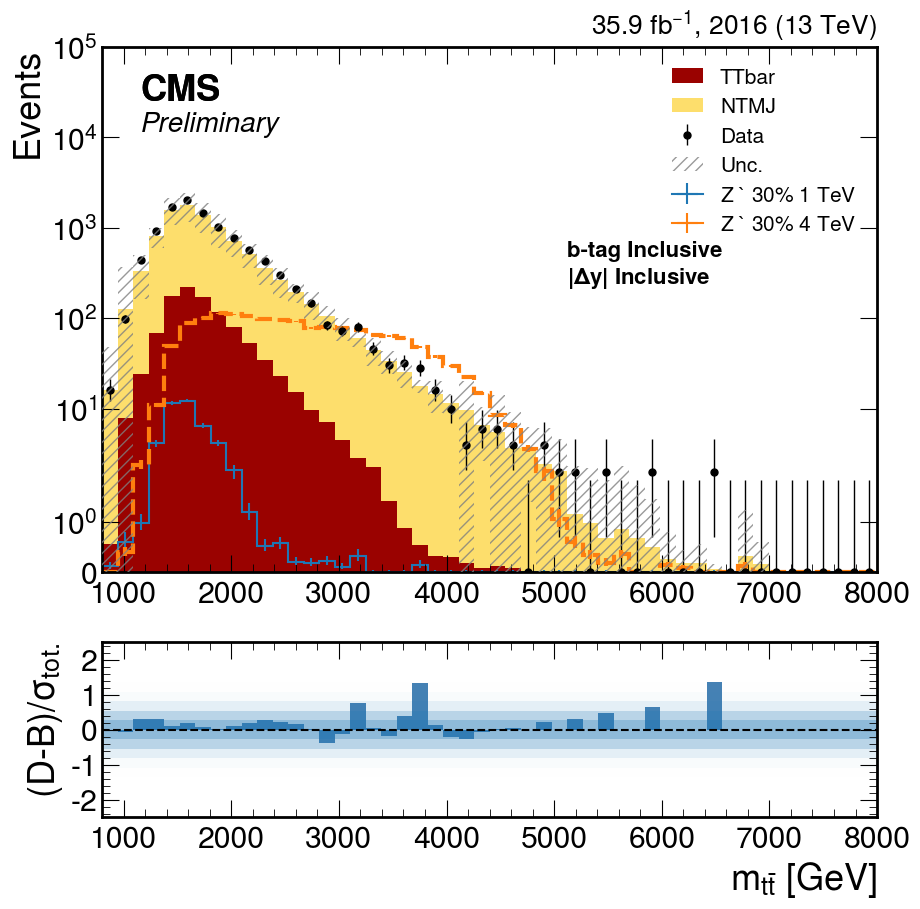

In [12]:
variable = 'ttbarmass_fine'  # Change this at will
signal = 'ZPrime30'
useSignal = True
usePull = True
Linear = False
# removeBkg = False
linearStr = ''
sigstr = ''
SaveFileName = f'../data/BkgEstEventCounts_Inc{oldHTstr}.txt'

# -- prepare to overwrite event-count txt -- #
file_to_delete = open(SaveFileName,'w')
file_to_delete.close()

if Linear:
    linearStr = '_LINEAR'
histDict = {}

dirname = 'closureTest'
if variable != 'ttbarmass':
    dirname = 'kinematics'
if useSignal:
    sigstr = '_with_' + signal
    
    
for IOV in IOVs:

    if 'Full' in IOV:
        histDict = UseFullIOV(variable, signal)
        SystemUnc = getSystUncFull(histDict, variable, signal, systematics, '', False)
#         SystemUncContam = getSystUncFull(histDict, variable, signal, systematics, '', True)
    elif '2016all' in IOV:
        histDict = Use2016allIOV(variable, signal)
        SystemUnc = getSystUnc2016all(histDict, variable, signal, systematics, '', False)
#         SystemUncContam = getSystUnc2016all(histDict, variable, signal, systematics, '', True)
    else:
        histDict = UseIOV(variable, signal)
        SystemUnc = getSystUnc(histDict, variable, signal, systematics, '', False)
#         SystemUncContam = getSystUnc(histDict, variable, signal, systematics, '', True)
        
    if Linear:
        text = f'Preliminary'
    else:
        text = f'Preliminary\n'

    plotBackgroundEstimate(histDict, SystemUnc, text, SaveFileName, True, '', signal, variable, Linear, usePull, useSignal)
        
    if usePull:
        savefilename = f'images/png/kinematics/{IOV}/{variable}{sigstr}_Inclusive{linearStr}.png'
    else:
        savefilename = f'images/png/{dirname}/{IOV}/{variable}{sigstr}_Inclusive{linearStr}.png'

    print(savefilename)
#     plt.savefig(savefilename)
#     plt.savefig(savefilename.replace('png', 'pdf'))

    plt.show()

## plot background estimate (by category)

{'700to1000': '/srv/outputs/TTbar_2016APV_700to1000.coffea', '1000toInf': '/srv/outputs/TTbar_2016APV_1000toInf.coffea'}
{'700to1000': '/srv/outputs/TTbar_2016APV_700to1000_bkgest.coffea', '1000toInf': '/srv/outputs/TTbar_2016APV_1000toInf_bkgest.coffea'}
/srv/outputs/QCD_2016APV_noSyst.coffea
/srv/outputs/QCD_2016APV_noSyst_bkgest.coffea
{'B': '/srv/outputs/JetHT_2016APVB_bkgest.coffea', 'C': '/srv/outputs/JetHT_2016APVC_bkgest.coffea', 'D': '/srv/outputs/JetHT_2016APVD_bkgest.coffea', 'E': '/srv/outputs/JetHT_2016APVE_bkgest.coffea', 'F': '/srv/outputs/JetHT_2016APVF_bkgest.coffea'}
{'B': '/srv/outputs/JetHT_2016APVB.coffea', 'C': '/srv/outputs/JetHT_2016APVC.coffea', 'D': '/srv/outputs/JetHT_2016APVD.coffea', 'E': '/srv/outputs/JetHT_2016APVE.coffea', 'F': '/srv/outputs/JetHT_2016APVF.coffea'}
{'B': '/srv/outputs/JetHT_2016APVB.coffea', 'C': '/srv/outputs/JetHT_2016APVC.coffea', 'D': '/srv/outputs/JetHT_2016APVD.coffea', 'E': '/srv/outputs/JetHT_2016APVE.coffea', 'F': '/srv/outputs/

/tmp/ipykernel_7235/1444983945.py:8: RuntimeWarning: divide by zero encountered in divide
  mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_7235/1444983945.py:8: RuntimeWarning: invalid value encountered in divide
  mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_7235/1444983945.py:12: RuntimeWarning: divide by zero encountered in divide
  term1 = np.where(HistDict['pretag'].values()>0., 1. / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_7235/1444983945.py:13: RuntimeWarning: divide by zero encountered in divide
  term2 = np.where( (Ndenom*mistag_data)>0., (np.ones(len(mistag_data))-mistag_data)/(Ndenom*mistag_data), 0. )
/tmp/ipykernel_7235/1444983945.py:19: RuntimeWarning: invalid value encountered in divide
  mmPercentErr = np.where( mmTerm2>0., mmTerm1/mmTerm2, 0. ) # Calculated percent error of the diffe

qcdClosure Percent Difference =  [ 0.63836654  0.0477426   0.04479925 -0.12744847 -0.15676991 -0.11034584
 -0.25544442 -0.36604135 -0.28912998 -0.50135046 -0.24598505 -0.5345118
 -0.38721075 -0.25271718 -0.28554158 -0.32776413 -0.22427137 -0.14737641
 -0.25668982 -0.17401957]
Mass Mod Percent Difference =  [-0.00316346 -0.00312288 -0.01438599  0.020017    0.05419981  0.01909336
 -0.04780442  0.20817077  0.09404687 -0.11248221 -0.22227684  0.3831345
  1.23073512 -2.         -2.          0.          0.          0.
  0.          0.        ]
mistagErr =  [ 7.0422001  19.66608955 18.97397292  8.85958871  4.79265219  2.63453582
  1.7850319   0.9579282   0.75627643  0.6144308   0.4194503   0.43210064
  0.1631624   0.21091732  0.          0.          0.          0.
  0.          0.        ]
massmodErr =  [ -0.50232413  -4.20212183 -19.17580555   5.6715257    4.18838644
   0.45280451  -0.44552319   0.58835023   0.13091219  -0.08936829
  -0.09821373   0.07133382   0.05444038  -0.08897223  -0.105

/opt/conda/lib/python3.10/site-packages/boost_histogram/_internal/view.py:192: RuntimeWarning: invalid value encountered in divide
  ufunc(
/opt/conda/lib/python3.10/site-packages/boost_histogram/_internal/view.py:198: RuntimeWarning: invalid value encountered in divide
  ufunc(


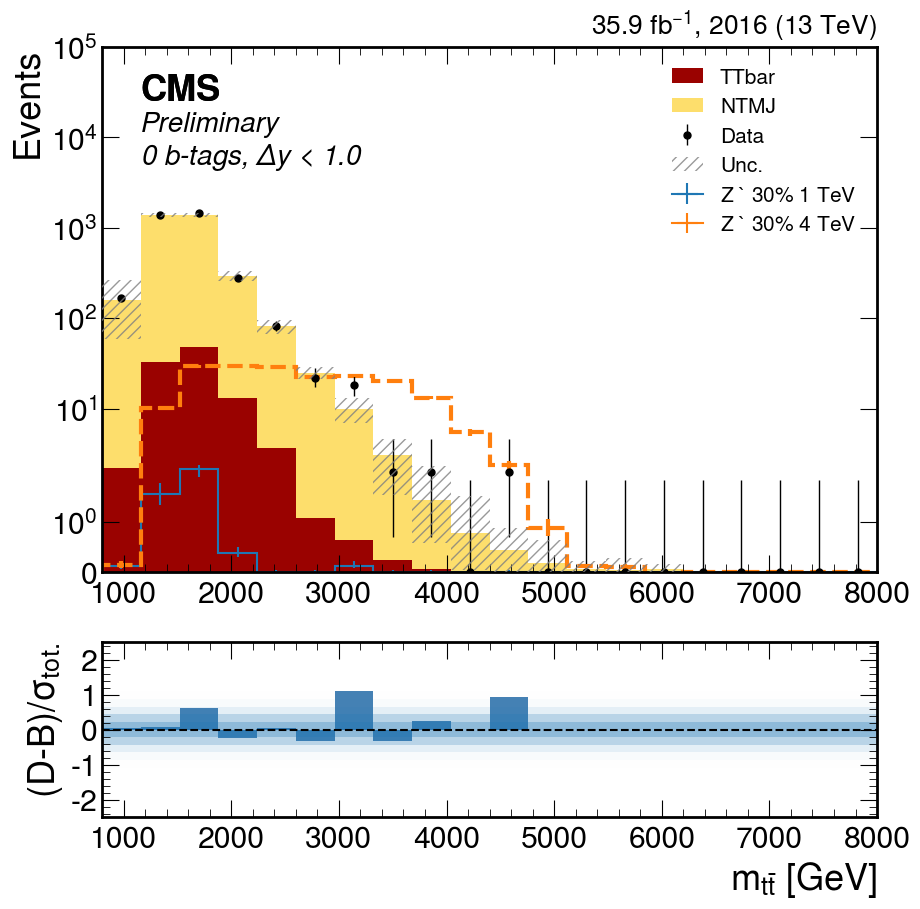

{'700to1000': '/srv/outputs/TTbar_2016APV_700to1000.coffea', '1000toInf': '/srv/outputs/TTbar_2016APV_1000toInf.coffea'}
{'700to1000': '/srv/outputs/TTbar_2016APV_700to1000_bkgest.coffea', '1000toInf': '/srv/outputs/TTbar_2016APV_1000toInf_bkgest.coffea'}
/srv/outputs/QCD_2016APV_noSyst.coffea
/srv/outputs/QCD_2016APV_noSyst_bkgest.coffea
{'B': '/srv/outputs/JetHT_2016APVB_bkgest.coffea', 'C': '/srv/outputs/JetHT_2016APVC_bkgest.coffea', 'D': '/srv/outputs/JetHT_2016APVD_bkgest.coffea', 'E': '/srv/outputs/JetHT_2016APVE_bkgest.coffea', 'F': '/srv/outputs/JetHT_2016APVF_bkgest.coffea'}
{'B': '/srv/outputs/JetHT_2016APVB.coffea', 'C': '/srv/outputs/JetHT_2016APVC.coffea', 'D': '/srv/outputs/JetHT_2016APVD.coffea', 'E': '/srv/outputs/JetHT_2016APVE.coffea', 'F': '/srv/outputs/JetHT_2016APVF.coffea'}
{'B': '/srv/outputs/JetHT_2016APVB.coffea', 'C': '/srv/outputs/JetHT_2016APVC.coffea', 'D': '/srv/outputs/JetHT_2016APVD.coffea', 'E': '/srv/outputs/JetHT_2016APVE.coffea', 'F': '/srv/outputs/

/tmp/ipykernel_7235/1444983945.py:8: RuntimeWarning: invalid value encountered in divide
  mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_7235/1444983945.py:12: RuntimeWarning: divide by zero encountered in divide
  term1 = np.where(HistDict['pretag'].values()>0., 1. / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_7235/1444983945.py:13: RuntimeWarning: divide by zero encountered in divide
  term2 = np.where( (Ndenom*mistag_data)>0., (np.ones(len(mistag_data))-mistag_data)/(Ndenom*mistag_data), 0. )
/tmp/ipykernel_7235/1444983945.py:19: RuntimeWarning: invalid value encountered in divide
  mmPercentErr = np.where( mmTerm2>0., mmTerm1/mmTerm2, 0. ) # Calculated percent error of the difference
/opt/conda/lib/python3.10/site-packages/boost_histogram/_internal/view.py:192: RuntimeWarning: invalid value encountered in divide
  ufunc(
/opt/conda/lib/python3.10/site-packages/boost_histogram/_internal/vi

qcdClosure Percent Difference =  [ 2.00000000e+00  2.00779298e-01 -1.14521055e-01 -1.62162960e-03
 -2.77182176e-01  2.57396652e-01 -1.54170008e-01 -3.96574327e-01
  2.79792063e-01  6.61822209e-01  1.35938917e+00 -4.89288721e-01
 -1.16822352e+00  1.50580615e+00  1.70655996e+00 -1.19260741e+00
  1.68664796e+00  1.72682671e+00  1.49680228e+00  1.04632750e+00]
Mass Mod Percent Difference =  [-3.91817306e-03 -2.64328891e-02 -2.94861569e-02  3.80738784e-03
 -6.41072384e-03 -1.58829810e-03 -5.77572896e-02  1.31104722e-02
 -1.88572316e-02 -1.94823163e-01 -5.28997018e-02 -1.25836049e-02
  1.86196544e-01 -8.99328983e-02 -6.68883082e-02 -3.01757040e-01
 -9.12398035e-01  0.00000000e+00  0.00000000e+00  2.00000000e+00]
mistagErr =  [ 2.02610033  7.96811338 15.49687973 13.67516413  9.71809491  6.70869975
  4.81098279  3.40347489  2.31060147  1.75218666  1.34846401  0.97559348
  0.53085637  0.47753254  0.4748595   0.36378732  0.2096888   0.
  0.          0.        ]
massmodErr =  [ -0.04813263  -5.65

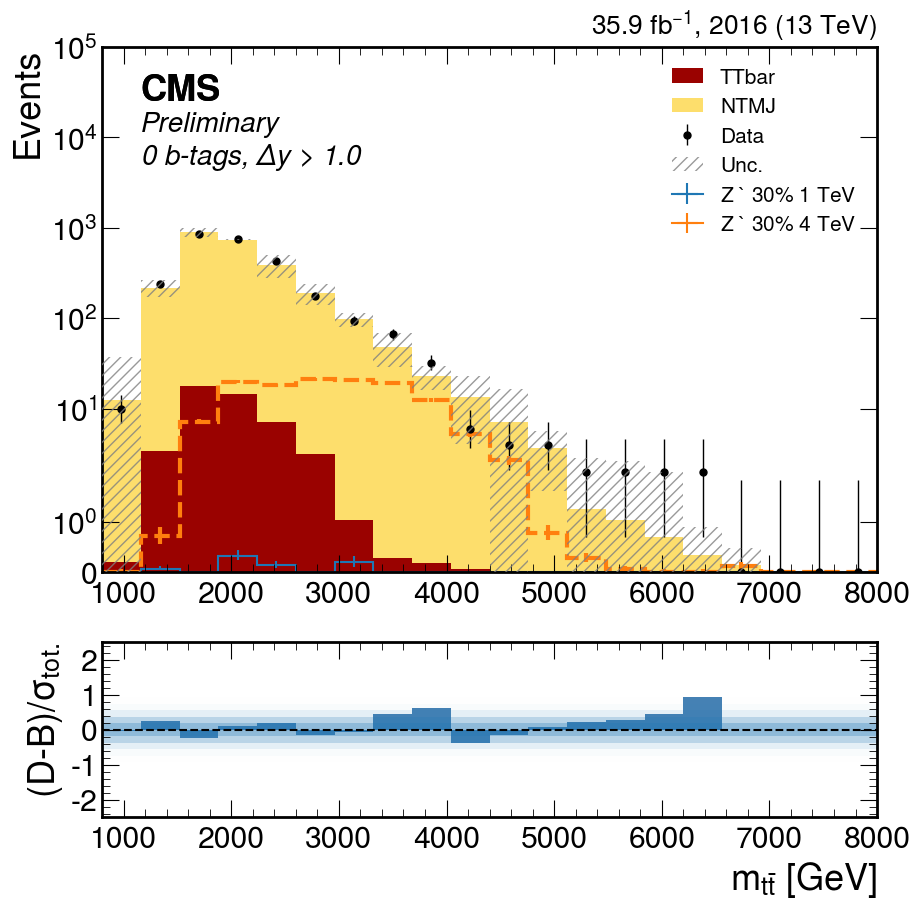

{'700to1000': '/srv/outputs/TTbar_2016APV_700to1000.coffea', '1000toInf': '/srv/outputs/TTbar_2016APV_1000toInf.coffea'}
{'700to1000': '/srv/outputs/TTbar_2016APV_700to1000_bkgest.coffea', '1000toInf': '/srv/outputs/TTbar_2016APV_1000toInf_bkgest.coffea'}
/srv/outputs/QCD_2016APV_noSyst.coffea
/srv/outputs/QCD_2016APV_noSyst_bkgest.coffea
{'B': '/srv/outputs/JetHT_2016APVB_bkgest.coffea', 'C': '/srv/outputs/JetHT_2016APVC_bkgest.coffea', 'D': '/srv/outputs/JetHT_2016APVD_bkgest.coffea', 'E': '/srv/outputs/JetHT_2016APVE_bkgest.coffea', 'F': '/srv/outputs/JetHT_2016APVF_bkgest.coffea'}
{'B': '/srv/outputs/JetHT_2016APVB.coffea', 'C': '/srv/outputs/JetHT_2016APVC.coffea', 'D': '/srv/outputs/JetHT_2016APVD.coffea', 'E': '/srv/outputs/JetHT_2016APVE.coffea', 'F': '/srv/outputs/JetHT_2016APVF.coffea'}
{'B': '/srv/outputs/JetHT_2016APVB.coffea', 'C': '/srv/outputs/JetHT_2016APVC.coffea', 'D': '/srv/outputs/JetHT_2016APVD.coffea', 'E': '/srv/outputs/JetHT_2016APVE.coffea', 'F': '/srv/outputs/

/tmp/ipykernel_7235/1444983945.py:8: RuntimeWarning: invalid value encountered in divide
  mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_7235/1444983945.py:12: RuntimeWarning: divide by zero encountered in divide
  term1 = np.where(HistDict['pretag'].values()>0., 1. / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_7235/1444983945.py:13: RuntimeWarning: divide by zero encountered in divide
  term2 = np.where( (Ndenom*mistag_data)>0., (np.ones(len(mistag_data))-mistag_data)/(Ndenom*mistag_data), 0. )
/tmp/ipykernel_7235/1444983945.py:19: RuntimeWarning: invalid value encountered in divide
  mmPercentErr = np.where( mmTerm2>0., mmTerm1/mmTerm2, 0. ) # Calculated percent error of the difference
/opt/conda/lib/python3.10/site-packages/boost_histogram/_internal/view.py:192: RuntimeWarning: invalid value encountered in divide
  ufunc(
/opt/conda/lib/python3.10/site-packages/boost_histogram/_internal/vi

qcdClosure Percent Difference =  [-1.00955283e+00 -1.29000564e-01 -2.09585224e-01 -2.78250310e-01
 -1.48709020e-01  1.04292750e-01 -3.17655798e-01  2.58894450e-02
 -2.81334690e-01 -1.79027085e-01  3.15494720e-01 -3.75864833e-02
 -5.16034627e-01 -9.77769474e-02  1.81456563e-01  4.73736227e-02
  2.36380505e-01  2.38764681e-01  1.51115286e-01  5.87939210e-04]
Mass Mod Percent Difference =  [-0.12984434 -0.02532136  0.00382311  0.00276652  0.0133301  -0.15039072
  0.06285232 -0.2816434  -0.08703243  0.68486763  0.96203998  0.00461344
 -2.08614764  0.          0.          0.          0.          0.
  0.          0.        ]
mistagErr =  [ 5.35986297 14.04317479 13.32949923  6.19541936  3.00806399  2.04767544
  1.14435684  0.83658426  0.68035688  0.20240017  0.17947729  0.29013901
  0.11430377  0.          0.          0.          0.          0.
  0.          0.        ]
massmodErr =  [-9.86811618e+00 -1.48963148e+01  2.19202157e+00  3.40344578e-01
  4.11914973e-01 -1.89533692e+00  2.57640024

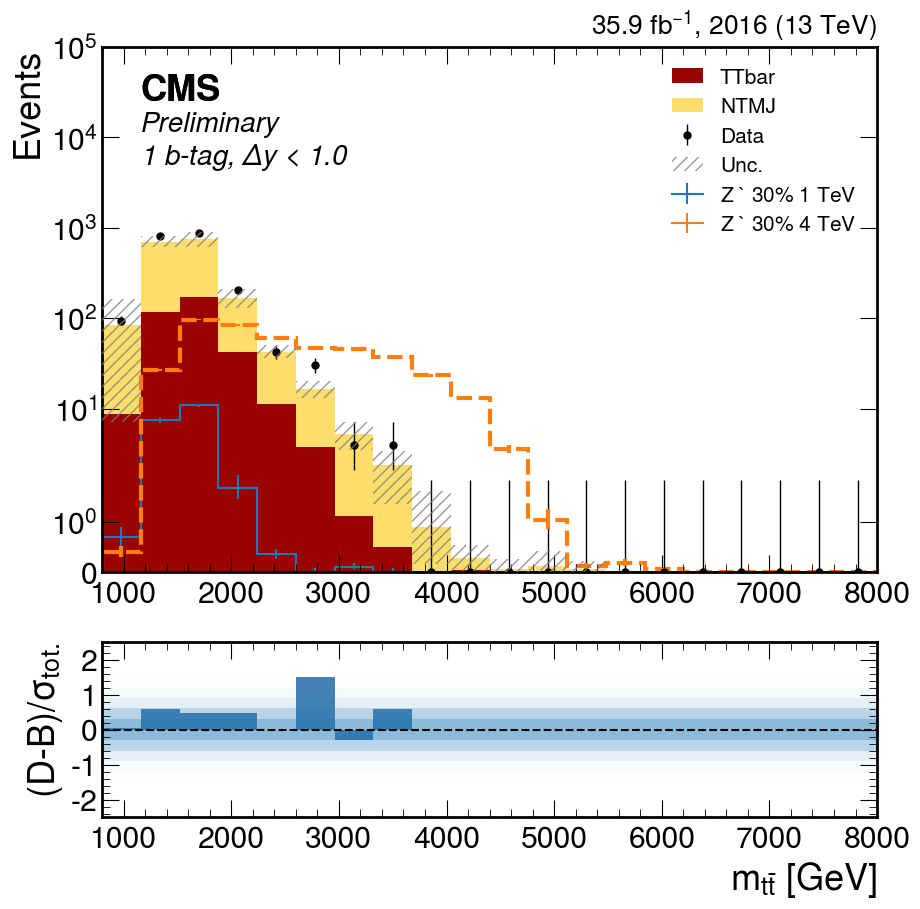

{'700to1000': '/srv/outputs/TTbar_2016APV_700to1000.coffea', '1000toInf': '/srv/outputs/TTbar_2016APV_1000toInf.coffea'}
{'700to1000': '/srv/outputs/TTbar_2016APV_700to1000_bkgest.coffea', '1000toInf': '/srv/outputs/TTbar_2016APV_1000toInf_bkgest.coffea'}
/srv/outputs/QCD_2016APV_noSyst.coffea
/srv/outputs/QCD_2016APV_noSyst_bkgest.coffea
{'B': '/srv/outputs/JetHT_2016APVB_bkgest.coffea', 'C': '/srv/outputs/JetHT_2016APVC_bkgest.coffea', 'D': '/srv/outputs/JetHT_2016APVD_bkgest.coffea', 'E': '/srv/outputs/JetHT_2016APVE_bkgest.coffea', 'F': '/srv/outputs/JetHT_2016APVF_bkgest.coffea'}
{'B': '/srv/outputs/JetHT_2016APVB.coffea', 'C': '/srv/outputs/JetHT_2016APVC.coffea', 'D': '/srv/outputs/JetHT_2016APVD.coffea', 'E': '/srv/outputs/JetHT_2016APVE.coffea', 'F': '/srv/outputs/JetHT_2016APVF.coffea'}
{'B': '/srv/outputs/JetHT_2016APVB.coffea', 'C': '/srv/outputs/JetHT_2016APVC.coffea', 'D': '/srv/outputs/JetHT_2016APVD.coffea', 'E': '/srv/outputs/JetHT_2016APVE.coffea', 'F': '/srv/outputs/

/tmp/ipykernel_7235/1444983945.py:8: RuntimeWarning: divide by zero encountered in divide
  mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_7235/1444983945.py:8: RuntimeWarning: invalid value encountered in divide
  mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_7235/1444983945.py:12: RuntimeWarning: divide by zero encountered in divide
  term1 = np.where(HistDict['pretag'].values()>0., 1. / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_7235/1444983945.py:13: RuntimeWarning: divide by zero encountered in divide
  term2 = np.where( (Ndenom*mistag_data)>0., (np.ones(len(mistag_data))-mistag_data)/(Ndenom*mistag_data), 0. )
/tmp/ipykernel_7235/1444983945.py:19: RuntimeWarning: invalid value encountered in divide
  mmPercentErr = np.where( mmTerm2>0., mmTerm1/mmTerm2, 0. ) # Calculated percent error of the diffe

qcdClosure Percent Difference =  [ 2.         -0.47739143 -0.60863141 -0.3510871  -0.26231585  0.16410447
 -0.39045752  1.45091235  1.26269497  1.03882906  1.75655432  1.54483699
  1.07327973 -1.53140309  1.9026916   1.68645399  1.94965832  1.79887155
  0.93888223  1.70970996]
Mass Mod Percent Difference =  [-0.27044209 -0.10277945 -0.00714135 -0.02626516  0.03371875 -0.00964437
 -0.03890436 -0.02826135  0.058088    0.01215474  0.31169727 -0.27688815
 -0.27897151 -0.11699078  0.94982714  2.          0.         -2.
  0.          0.        ]
mistagErr =  [ 1.31790452  6.08758896 10.88553845  9.66076713  6.54296909  4.7587534
  3.15572626  2.45653217  1.68569874  1.44721459  0.91493276  0.8215429
  0.39168499  0.47796422  0.1223856   0.          0.17499703  0.
  0.          0.        ]
massmodErr =  [ -1.34453156 -10.19349441  -2.63072925  -8.1551156    5.16232279
  -0.78268365  -1.47687414  -0.60178259   0.61131039   0.07959832
   0.93755051  -0.53825418  -0.23304254  -0.07717861   0.077

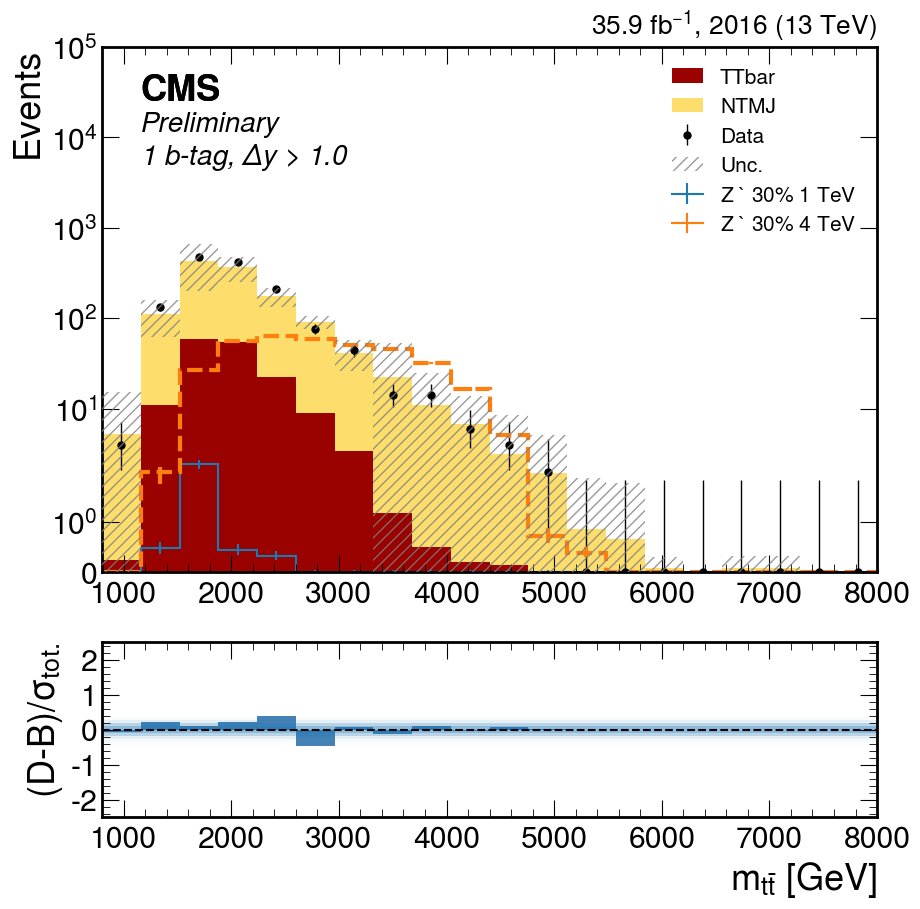

{'700to1000': '/srv/outputs/TTbar_2016APV_700to1000.coffea', '1000toInf': '/srv/outputs/TTbar_2016APV_1000toInf.coffea'}
{'700to1000': '/srv/outputs/TTbar_2016APV_700to1000_bkgest.coffea', '1000toInf': '/srv/outputs/TTbar_2016APV_1000toInf_bkgest.coffea'}
/srv/outputs/QCD_2016APV_noSyst.coffea
/srv/outputs/QCD_2016APV_noSyst_bkgest.coffea
{'B': '/srv/outputs/JetHT_2016APVB_bkgest.coffea', 'C': '/srv/outputs/JetHT_2016APVC_bkgest.coffea', 'D': '/srv/outputs/JetHT_2016APVD_bkgest.coffea', 'E': '/srv/outputs/JetHT_2016APVE_bkgest.coffea', 'F': '/srv/outputs/JetHT_2016APVF_bkgest.coffea'}
{'B': '/srv/outputs/JetHT_2016APVB.coffea', 'C': '/srv/outputs/JetHT_2016APVC.coffea', 'D': '/srv/outputs/JetHT_2016APVD.coffea', 'E': '/srv/outputs/JetHT_2016APVE.coffea', 'F': '/srv/outputs/JetHT_2016APVF.coffea'}
{'B': '/srv/outputs/JetHT_2016APVB.coffea', 'C': '/srv/outputs/JetHT_2016APVC.coffea', 'D': '/srv/outputs/JetHT_2016APVD.coffea', 'E': '/srv/outputs/JetHT_2016APVE.coffea', 'F': '/srv/outputs/

/tmp/ipykernel_7235/1444983945.py:8: RuntimeWarning: divide by zero encountered in divide
  mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_7235/1444983945.py:8: RuntimeWarning: invalid value encountered in divide
  mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_7235/1444983945.py:12: RuntimeWarning: divide by zero encountered in divide
  term1 = np.where(HistDict['pretag'].values()>0., 1. / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_7235/1444983945.py:13: RuntimeWarning: divide by zero encountered in divide
  term2 = np.where( (Ndenom*mistag_data)>0., (np.ones(len(mistag_data))-mistag_data)/(Ndenom*mistag_data), 0. )
/tmp/ipykernel_7235/1444983945.py:19: RuntimeWarning: invalid value encountered in divide
  mmPercentErr = np.where( mmTerm2>0., mmTerm1/mmTerm2, 0. ) # Calculated percent error of the diffe

qcdClosure Percent Difference =  [ 0.          2.          0.1687069   1.7076999   0.06818844  0.26060876
  0.46164957  0.47040335 -0.25661006 -0.40662135 -0.7310598  -0.50397024
  0.36081386 -0.17965313  1.66595594  0.96880676  0.0367292   0.67842184
  0.          0.        ]
Mass Mod Percent Difference =  [-0.87204465 -0.25537735 -0.07203487 -0.18036047  0.09472726  0.0513227
  0.38082478 -1.06522126 -2.18942097  0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.        ]
mistagErr =  [ 2.22236116  5.86615307  5.39681316  2.44013128  1.36865797  1.13679687
  0.44729514  0.3839284   0.26859442 -0.         -0.         -0.
  0.          0.          0.          0.          0.          0.
  0.          0.        ]
massmodErr =  [ -8.64129898 -19.52625849  -4.9327534   -2.77715265   0.4521155
   0.11691862   0.18581609  -0.34641861  -0.35476625  -0.
  -0.          -0.           0.           0.           0.
   0.           0.        

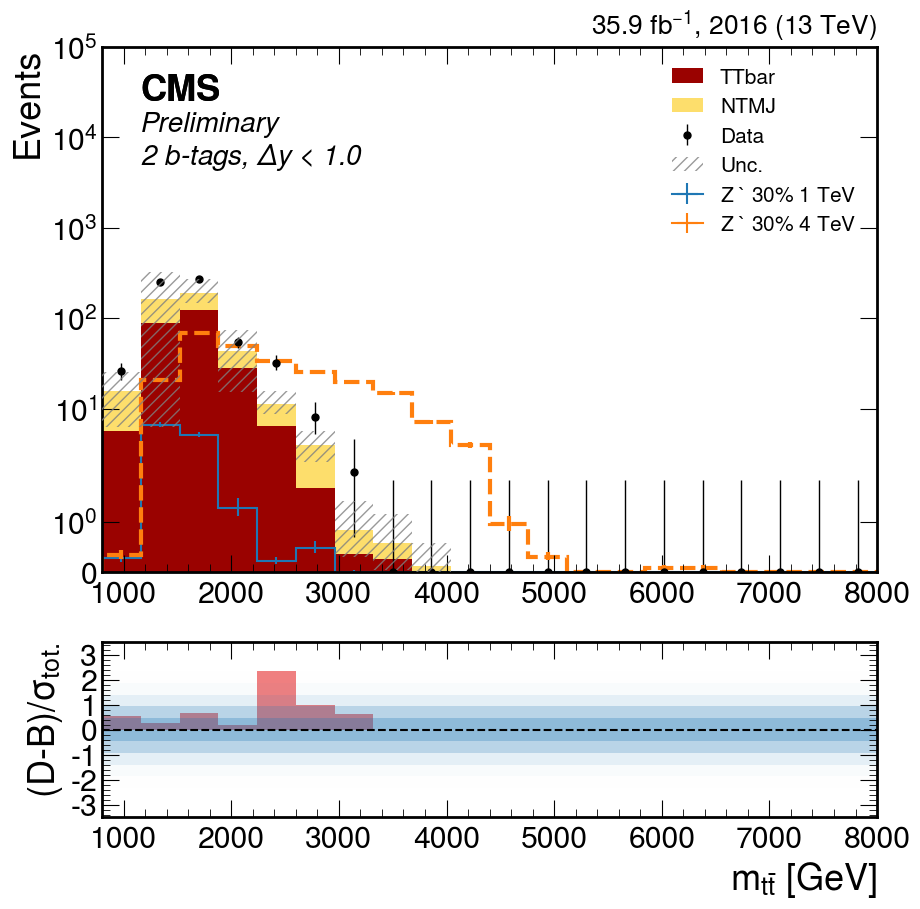

{'700to1000': '/srv/outputs/TTbar_2016APV_700to1000.coffea', '1000toInf': '/srv/outputs/TTbar_2016APV_1000toInf.coffea'}
{'700to1000': '/srv/outputs/TTbar_2016APV_700to1000_bkgest.coffea', '1000toInf': '/srv/outputs/TTbar_2016APV_1000toInf_bkgest.coffea'}
/srv/outputs/QCD_2016APV_noSyst.coffea
/srv/outputs/QCD_2016APV_noSyst_bkgest.coffea
{'B': '/srv/outputs/JetHT_2016APVB_bkgest.coffea', 'C': '/srv/outputs/JetHT_2016APVC_bkgest.coffea', 'D': '/srv/outputs/JetHT_2016APVD_bkgest.coffea', 'E': '/srv/outputs/JetHT_2016APVE_bkgest.coffea', 'F': '/srv/outputs/JetHT_2016APVF_bkgest.coffea'}
{'B': '/srv/outputs/JetHT_2016APVB.coffea', 'C': '/srv/outputs/JetHT_2016APVC.coffea', 'D': '/srv/outputs/JetHT_2016APVD.coffea', 'E': '/srv/outputs/JetHT_2016APVE.coffea', 'F': '/srv/outputs/JetHT_2016APVF.coffea'}
{'B': '/srv/outputs/JetHT_2016APVB.coffea', 'C': '/srv/outputs/JetHT_2016APVC.coffea', 'D': '/srv/outputs/JetHT_2016APVD.coffea', 'E': '/srv/outputs/JetHT_2016APVE.coffea', 'F': '/srv/outputs/

/tmp/ipykernel_7235/1444983945.py:8: RuntimeWarning: divide by zero encountered in divide
  mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_7235/1444983945.py:8: RuntimeWarning: invalid value encountered in divide
  mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_7235/1444983945.py:12: RuntimeWarning: divide by zero encountered in divide
  term1 = np.where(HistDict['pretag'].values()>0., 1. / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_7235/1444983945.py:13: RuntimeWarning: divide by zero encountered in divide
  term2 = np.where( (Ndenom*mistag_data)>0., (np.ones(len(mistag_data))-mistag_data)/(Ndenom*mistag_data), 0. )
/tmp/ipykernel_7235/1444983945.py:19: RuntimeWarning: invalid value encountered in divide
  mmPercentErr = np.where( mmTerm2>0., mmTerm1/mmTerm2, 0. ) # Calculated percent error of the diffe

qcdClosure Percent Difference =  [ 0.          2.         -0.7813805   1.03102905 -0.79702269  0.6266915
  1.3217895   1.96708868 -1.52050982  1.83850657  2.          1.41471143
  1.17245913  1.33835293  1.54407336  2.          2.          0.
  0.          0.        ]
Mass Mod Percent Difference =  [-0.83986666 -0.64532672 -0.17859556 -0.1214853   0.03174593  0.00478669
 -0.04876752 -0.33016078 -0.29521091  0.32012968  0.06934425 -0.18929431
 -0.00387461 -0.36330545  0.          0.         -2.          0.
  0.          0.        ]
mistagErr =  [0.4052014  2.49388996 4.13666032 3.54707944 2.69119273 1.69927169
 1.14839736 0.79210905 0.55774481 0.39950165 0.50328885 0.37160385
 0.27239608 0.24246638 0.         0.         0.         0.
 0.         0.        ]
massmodErr =  [-2.54576544e-01 -8.29614209e+00 -7.89861247e+00 -4.37936735e+00
  6.12798205e-01  4.43095604e-02 -2.44448541e-01 -8.33989917e-01
 -3.22770091e-01  2.05968742e-01  3.87803386e-02 -4.24608467e-02
 -9.60291435e-04 -4.1530

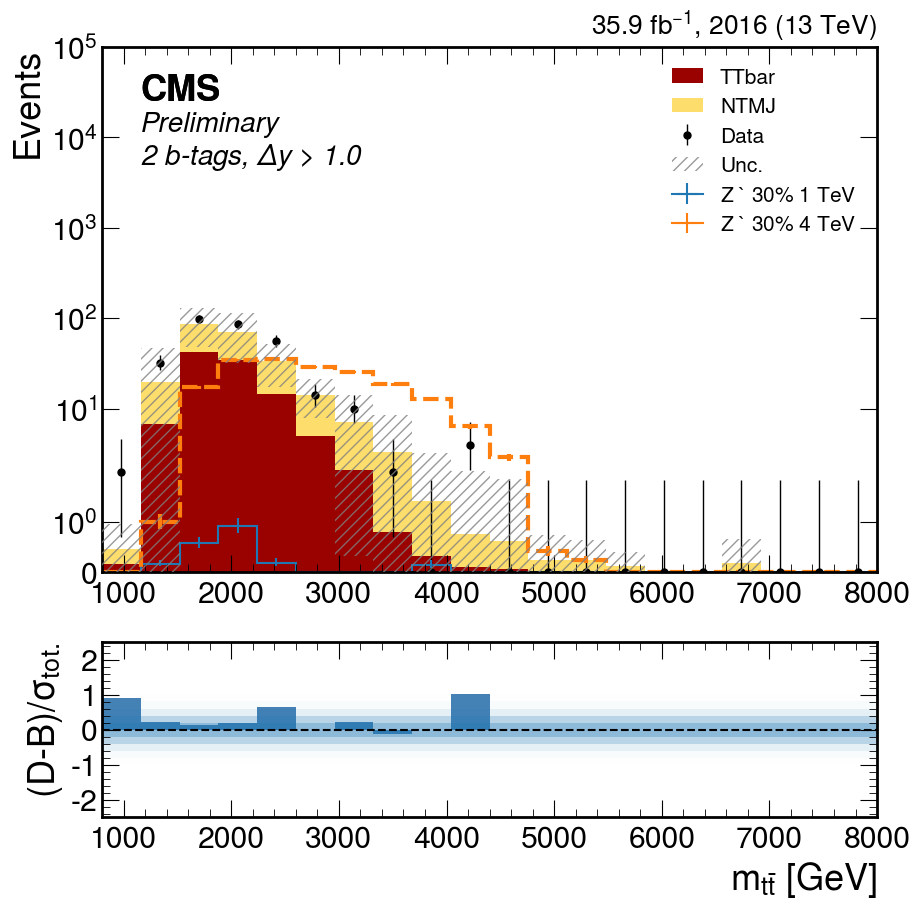

In [14]:
variable = 'ttbarmass'  # Change this at will
signal = 'ZPrime30'
useSignal = True
usePull = True
Linear = False
linearStr = ''
sigstr = ''

SaveFileName = f'../data/BkgEstEventCounts_Categories{oldHTstr}.txt'

# -- prepare to overwrite event-count txt -- #
file_to_delete = open(SaveFileName,'w')
file_to_delete.close()

if Linear:
    linearStr = '_LINEAR'
histDict = {}

dirname = 'closureTest'
if variable != 'ttbarmass':
    dirname = 'kinematics'
if useSignal:
    sigstr = '_with_' + signal
    
for IOV in IOVs:
    
    for cat in ['0bcen', '0bfwd', '1bcen', '1bfwd', '2bcen', '2bfwd']:
    # for cat in ['2bcen', '2bfwd']:

        if 'Full' in IOV:
            histDict = UseFullIOV(variable, signal, cat)
            SystemUnc = getSystUncFull(histDict, variable, signal, systematics, cat, False)
#             SystemUncContam = getSystUncFull(histDict, variable, signal, systematics, cat, True)
        elif '2016all' in IOV:
            histDict = Use2016allIOV(variable, signal, cat)
            SystemUnc = getSystUnc2016all(histDict, variable, signal, systematics, cat, False)
#             SystemUncContam = getSystUnc2016all(histDict, variable, signal, systematics, cat, True)
        else:
            histDict = UseIOV(variable, signal, cat)
            SystemUnc = getSystUnc(histDict, variable, signal, systematics, cat, False)
#             SystemUncContam = getSystUnc(histDict, variable, signal, systematics, cat, True)
            
        dytext = ''
        if 'cen' in cat:
            dytext = r'$\Delta y$ < 1.0'
        elif 'fwd' in cat:
            dytext = r'$\Delta y$ > 1.0'

        btext = ''
        if '0b' in cat:
            btext = '0 b-tags'
        elif '1b' in cat:
            btext = '1 b-tag'
        elif '2b' in cat:
            btext = '2 b-tags'

        if Linear:
            text = f'Preliminary:    {btext}, {dytext}'
        else:
            text = f'Preliminary\n{btext}, {dytext} \n'

        plotBackgroundEstimate(histDict, SystemUnc, text, SaveFileName, False, '', signal, variable, Linear, usePull, useSignal)

        if usePull:
            savefilename = f'images/png/kinematics/{IOV}/{variable}{sigstr}_{cat}{linearStr}.png'
        else:
            savefilename = f'images/png/{dirname}/{IOV}/{variable}{sigstr}_{cat}{linearStr}.png'

        print(savefilename)
#         plt.savefig(savefilename)
#         plt.savefig(savefilename.replace('png', 'pdf'))

        plt.show()

# Comparison without Mass Modification (Inclusive)

In [ ]:
variable = 'ttbarmass'  # Change this at will
signal = 'ZPrime30'
useSignal = False
usePull = True
Linear = True
# removeBkg = False
linearStr = ''
sigstr = ''
if Linear:
    linearStr = '_LINEAR'
histDict = {}

dirname = 'closureTest'
if variable != 'ttbarmass':
    dirname = 'kinematics'
if useSignal:
    sigstr = '_with_' + signal
    
    
for IOV in IOVs:

    if 'Full' in IOV:
        histDict = UseFullIOV(variable, signal)
    elif '2016all' in IOV:
        histDict = Use2016allIOV(variable, signal)
    else:
        histDict = UseIOV(variable, signal)

    if Linear:
        text = f'Preliminary'
    else:
        text = f'Preliminary\n'

    plotBackgroundEstimateComparison(histDict, text, True, signal, variable, Linear, usePull, useSignal)
        
    if usePull:
        savefilename = f'images/png/kinematics/{IOV}/{variable}{sigstr}_Inclusive{linearStr}.png'
    else:
        savefilename = f'images/png/{dirname}/{IOV}/{variable}{sigstr}_Inclusive{linearStr}.png'
        

    print(savefilename)
#     plt.savefig(savefilename)
#     plt.savefig(savefilename.replace('png', 'pdf'))

    plt.show()

# Comparison without Mass Modification (Categories)

In [ ]:
# variable = 'ttbarmass'  # Change this at will
# signal = 'ZPrime1'
# useSignal = False
# usePull = True
# Linear = True
# linearStr = ''
# sigstr = ''
# if Linear:
#     linearStr = '_LINEAR'
# histDict = {}

# dirname = 'closureTest'
# if variable != 'ttbarmass':
#     dirname = 'kinematics'
# if useSignal:
#     sigstr = '_with_' + signal
    
# for IOV in IOVs:
    
#     for cat in ['0bcen', '0bfwd', '1bcen', '1bfwd', '2bcen', '2bfwd']:

#         if 'Full' in IOV:
#             histDict = UseFullIOV(variable, signal, cat)
#         elif '2016all' in IOV:
#             histDict = Use2016allIOV(variable, signal, cat)
#         else:
#             histDict = UseIOV(variable, signal, cat)
            
#         dytext = ''
#         if 'cen' in cat:
#             dytext = r'$\Delta y$ < 1.0'
#         elif 'fwd' in cat:
#             dytext = r'$\Delta y$ > 1.0'

#         btext = ''
#         if '0b' in cat:
#             btext = '0 b-tags'
#         elif '1b' in cat:
#             btext = '1 b-tag'
#         elif '2b' in cat:
#             btext = '2 b-tags'

#         if Linear:
#             text = f'Preliminary:    {btext}, {dytext}'
#         else:
#             text = f'Preliminary\n{btext}, {dytext} \n'

#         plotBackgroundEstimateComparison(histDict, text, False, signal, variable, Linear, usePull, useSignal)

#         if usePull:
#             savefilename = f'images/png/kinematics/{IOV}/{variable}{sigstr}_{cat}{linearStr}.png'
#         else:
#             savefilename = f'images/png/{dirname}/{IOV}/{variable}{sigstr}_{cat}{linearStr}.png'

#         print(savefilename)
# #         plt.savefig(savefilename)
# #         plt.savefig(savefilename.replace('png', 'pdf'))

#         plt.show()

In [ ]:
# Signals = {
#     'ZPrime1' : ['1000', '2000', '3000', '4000'],
#     'ZPrime10': ['1000', '2000', '3000', '4000'],
#     'ZPrime30': ['1000', '2000', '3000', '4000'],
#     'ZPrimeDM': ['1000', '1500', '2000', '2500', '3000', '3500', '4000', '4500', '5000'],
#     'RSGluon':  ['1000', '1500', '2000', '2500', '3000', '3500', '4000', '4500', '5000']
# }

# signal = 'ZPrime30'

# IOV = '2016all'

# cats = ['0bcen', '0bfwd', '1bcen', '1bfwd', '2bcen', '2bfwd']
# cat_labels = ['cen0b', 'fwd0b', 'cen1b', 'fwd1b', 'cen2b', 'fwd2b']

# # systematics = [
# #         'jes',
# #         'jer',
# #         'pileup',
# #         'pdf',
# #         'q2',
# #         'btag',
# #         'toptagsf',
# #         'toptagxs',
# #         'lumi',
# #         'prefiring'
# #     ]
# syst_labels = ['nominal']
# for s in systematics:
#     if not 'nominal' in s:
#         syst_labels.append(s+'Down')
#         syst_labels.append(s+'Up')
        
# print(syst_labels)

# savefileheader = '../outputs/combine/TTbarAllHad{}_'.format(IOV.replace('20', '').replace('all',''))
# print(savefileheader)

# froot = uproot.recreate(savefileheader+'CombineRoot_Cat.root')

# variable = 'ttbarmass'



# # for cat, catname in zip(cats, cat_labels):
# #     signal_cat = label_to_int_dict['2t'+cat]
# #     pretag_cat = label_to_int_dict['pret'+cat]
# #     httbar_trial = getHist(variable, 'TTbar', False, '2017', sum_axes=[], integrate_axes={'anacat':signal_cat})
# #     print(httbar_trial)



# # for IOV in IOVs:

# for cat, catname in zip(cats, cat_labels):

#     signal_cat = label_to_int_dict['2t'+cat]
#     pretag_cat = label_to_int_dict['pret'+cat]

#     hsignal = {}
#     hsignal['ZPrime1'] = {}
#     hsignal['ZPrime10'] = {}
#     hsignal['ZPrime30'] = {}
#     hsignal['ZPrimeDM'] = {}
#     hsignal['RSGluon'] = {}

#     HistDict = Use2016allIOV(variable, signal, cat)
#     Hbkg = HistDict['ntmj'] + HistDict['ttbar']
#     Hbkg_fixed = HistDict['ntmj_fixed'] + HistDict['ttbar']
#     Ndenom = HistDict['antitag_data'].values() - HistDict['antitag_ttbar'].values()
#     mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
#     term1 = np.where(HistDict['pretag'].values()>0., 1. / HistDict['pretag'].values(), 0.)
#     term2 = np.where( (Ndenom*mistag_data)>0., (np.ones(len(mistag_data))-mistag_data)/(Ndenom*mistag_data), 0. ) 
#     mistagErrProp =  HistDict['ntmj_fixed']*np.sqrt( term1 + term2 )# 1 + 2 = mistag error & stat. error of NTMJ
    
#     mmTerm1 = (HistDict['ntmj_fixed_noMM'].values() - HistDict['ntmj_fixed'].values()) # "source" of Mass Mod error
#     mmTerm2 = (HistDict['ntmj_fixed_noMM'].values() + HistDict['ntmj_fixed'].values()) / 2.
#     mmPercentErr = np.where( mmTerm2>0., mmTerm1/mmTerm2, 0. ) # Calculated percent error of the difference
#     mmErrProp = HistDict['ntmj_fixed']*np.abs(mmPercentErr) # Mass Mod error
    
#     qcdTerm1 = (HistDict['QCDbkgest'].values() - HistDict['QCDsignal'].values()) # "source" of QCD closure error
#     qcdTerm2 = (HistDict['QCDbkgest'].values() + HistDict['QCDsignal'].values()) / 2.
#     qcdPercentErr = np.where((qcdTerm2 > 10**(-4)), qcdTerm1/qcdTerm2, 0.) # Calculated percent error of the difference
#     qcdErrProp = HistDict['ntmj_fixed']*np.abs(qcdPercentErr) #QCD closure error
#     # qcdErrProp = np.zeros(len(qcdTerm1)) # temporarily turn off QCD ERROR for testing

#     froot["bkgest_"+catname+'_mistagUp'] = mistagErrProp
#     froot["bkgest_"+catname+'_mistagDown'] = mistagErrProp

#     froot["bkgest_"+catname+'_massmodUp'] = mmErrProp
#     froot["bkgest_"+catname+'_massmodDown'] = mmErrProp

#     froot["bkgest_"+catname+'_qcdclosureUp'] = qcdErrProp
#     froot["bkgest_"+catname+'_qcdclosureDown'] = qcdErrProp

#     for syst in syst_labels:

#         if 'Full' in IOV:

#             catsystString = catname+'_'+syst

#             httbar_apv        = getHist(variable, 'TTbar', False, '2016APV', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst})
#             hcontam_apv       = getHist(variable, 'TTbar', True, '2016APV', sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':syst})
#             httbar_noapv      = getHist(variable, 'TTbar', False, '2016', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst})
#             hcontam_noapv     = getHist(variable, 'TTbar', True, '2016', sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':syst})
#             httbar_17      = getHist(variable, 'TTbar', False, '2017', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst})
#             hcontam_17     = getHist(variable, 'TTbar', True, '2017', sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':syst})
#             httbar_18      = getHist(variable, 'TTbar', False, '2018', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst})
#             hcontam_18     = getHist(variable, 'TTbar', True, '2018', sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':syst})

#             print('loading signals...')
#             for sig in Signals.keys():
#                 for mass in Signals[sig]:
#                     hsignal_apv   = getHist(variable, sig, False, '2016APV', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst}, masspoint=mass)
#                     hsignal_noapv = getHist(variable, sig, False, '2016', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst}, masspoint=mass)
#                     hsignal_17 = getHist(variable, sig, False, '2017', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst}, masspoint=mass)
#                     hsignal_18 = getHist(variable, sig, False, '2018', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst}, masspoint=mass)
#                     hsignal[sig][mass] = hsignal_apv + hsignal_noapv + hsignal_17 + hsignal_18

#             httbar  = httbar_apv + httbar_noapv + httbar_17 + httbar_18
#             hcontam = hcontam_apv + hcontam_noapv + hcontam_17 + hcontam_18

#             print('filling root files...')
#             if 'nominal' in syst:
#                 syst = ''
#                 catsystString = catname+syst
#                 hntmj_apv   = getHist(variable, 'JetHT', True, '2016APV',   sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':'nominal'})
#                 hdata_apv   = getHist(variable, 'JetHT', False, '2016APV',  sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':'nominal'})
#                 hntmj_noapv = getHist(variable, 'JetHT', True, '2016',   sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':'nominal'})
#                 hdata_noapv = getHist(variable, 'JetHT', False, '2016',  sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':'nominal'})
#                 hntmj_17 = getHist(variable, 'JetHT', True, '2017',   sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':'nominal'})
#                 hdata_17 = getHist(variable, 'JetHT', False, '2017',  sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':'nominal'})
#                 hntmj_18 = getHist(variable, 'JetHT', True, '2018',   sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':'nominal'})
#                 hdata_18 = getHist(variable, 'JetHT', False, '2018',  sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':'nominal'})

#                 hntmj = hntmj_apv + hntmj_noapv + hntmj_17 + hntmj_18
#                 hdata = hdata_apv + hdata_noapv + hdata_17 + hdata_18
#                 hntmj_fixed = hntmj + -1*hcontam
#                 print('data_obs_'+catsystString+'\nbkgest_'+catsystString)
#                 froot["data_obs_"+catsystString] = hdata
#                 froot["bkgest_"+catsystString] = hntmj_fixed

#             print('TTbar_'+catsystString)
#             froot["TTbar_"+catsystString] = httbar


#             for sig in Signals.keys():

#                 if 'RSGluon' not in sig:
#                     if sig != 'ZPrime1': # ZPrime10, 30 and DM
#                         [print(sig[:-2]+mass+'_'+sig[-2:]+'_'+catsystString) for mass in Signals[sig]]
#                         for mass in Signals[sig]:
#                             froot[sig[:-2]+mass+'_'+sig[-2:]+'_'+catsystString] = hsignal[sig][mass]
#                     else: # ZPrime1
#                         [print(sig[:-1]+mass+'_'+sig[-1:]+'_'+catsystString) for mass in Signals[sig]]
#                         for mass in Signals[sig]:
#                             froot[sig[:-1]+mass+'_'+sig[-1:]+'_'+catsystString] = hsignal[sig][mass]
#                 else: # RSGluon
#                     [print(sig+mass+'_'+catsystString) for mass in Signals[sig]]
#                     for mass in Signals[sig]:
#                         froot[sig+mass+'_'+catsystString] = hsignal[sig][mass]

#             # -- quick nominal plot to see how hists look -- #
# #                 if syst == '':
#             dytext = ''
#             if 'cen' in cat:
#                 dytext = r'$\Delta y$ < 1.0'
#             elif 'fwd' in cat:
#                 dytext = r'$\Delta y$ > 1.0'

#             btext = ''
#             if '0b' in cat:
#                 btext = '0 b-tags'
#             elif '1b' in cat:
#                 btext = '1 b-tag'
#             elif '2b' in cat:
#                 btext = '2 b-tags'

#             text = f'data/simulation\n{btext}, {dytext} \n'

#             plotBackgroundEstimate(variable, hdata, hntmj_fixed, httbar, IOV, text, signal, hsignal['ZPrime1']['3000'], hsignal['ZPrime10']['3000'], hsignal['ZPrime30']['3000'], hsignal['ZPrimeDM']['3000'])
#             plt.show()
            
#         elif '2016all' in IOV:

#             catsystString = catname+'_'+syst

#             httbar_apv        = getHist(variable, 'TTbar', False, '2016APV', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst})
#             hcontam_apv       = getHist(variable, 'TTbar', True, '2016APV', sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':syst})
#             httbar_noapv      = getHist(variable, 'TTbar', False, '2016', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst})
#             hcontam_noapv     = getHist(variable, 'TTbar', True, '2016', sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':syst})

#             print('loading signals...')
#             for sig in Signals.keys():
#                 for mass in Signals[sig]:
#                     hsignal_apv   = getHist(variable, sig, False, '2016APV', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst}, masspoint=mass)
#                     hsignal_noapv = getHist(variable, sig, False, '2016', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst}, masspoint=mass)
#                     hsignal[sig][mass] = hsignal_apv + hsignal_noapv

#             httbar  = httbar_apv + httbar_noapv
#             hcontam = hcontam_apv + hcontam_noapv

#             print('filling root files...')
#             if 'nominal' in syst:
#                 syst = ''
#                 catsystString = catname+syst
#                 hntmj_apv   = getHist(variable, 'JetHT', True, '2016APV',   sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':'nominal'})
#                 hdata_apv   = getHist(variable, 'JetHT', False, '2016APV',  sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':'nominal'})
#                 hntmj_noapv = getHist(variable, 'JetHT', True, '2016',   sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':'nominal'})
#                 hdata_noapv = getHist(variable, 'JetHT', False, '2016',  sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':'nominal'})

#                 hntmj = hntmj_apv + hntmj_noapv
#                 hdata = hdata_apv + hdata_noapv
#                 hntmj_fixed = hntmj + -1*hcontam
#                 print('data_obs_'+catsystString+'\nbkgest_'+catsystString)
#                 froot["data_obs_"+catsystString] = hdata
#                 froot["bkgest_"+catsystString] = hntmj_fixed

#             print('TTbar_'+catsystString)
#             froot["TTbar_"+catsystString] = httbar


#             for sig in Signals.keys():

#                 if 'RSGluon' not in sig:
#                     if sig != 'ZPrime1': # ZPrime10, 30 and DM
#                         [print(sig[:-2]+mass+'_'+sig[-2:]+'_'+catsystString) for mass in Signals[sig]]
#                         for mass in Signals[sig]:
#                             froot[sig[:-2]+mass+'_'+sig[-2:]+'_'+catsystString] = hsignal[sig][mass]
#                     else: # ZPrime1
#                         [print(sig[:-1]+mass+'_'+sig[-1:]+'_'+catsystString) for mass in Signals[sig]]
#                         for mass in Signals[sig]:
#                             froot[sig[:-1]+mass+'_'+sig[-1:]+'_'+catsystString] = hsignal[sig][mass]
#                 else: # RSGluon
#                     [print(sig+mass+'_'+catsystString) for mass in Signals[sig]]
#                     for mass in Signals[sig]:
#                         froot[sig+mass+'_'+catsystString] = hsignal[sig][mass]

#             # -- quick nominal plot to see how hists look -- #
# #                 if syst == '':
#             dytext = ''
#             if 'cen' in cat:
#                 dytext = r'$\Delta y$ < 1.0'
#             elif 'fwd' in cat:
#                 dytext = r'$\Delta y$ > 1.0'

#             btext = ''
#             if '0b' in cat:
#                 btext = '0 b-tags'
#             elif '1b' in cat:
#                 btext = '1 b-tag'
#             elif '2b' in cat:
#                 btext = '2 b-tags'

#             text = f'\n{btext}, {dytext} \n'

#             # plotBackgroundEstimate(variable, hdata, hntmj_fixed, httbar, IOV, text, signal, hsignal['ZPrime1']['3000'], hsignal['ZPrime10']['3000'], hsignal['ZPrime30']['3000'], hsignal['ZPrimeDM']['3000'])
#             # plt.show()
#         else:

#             catsystString = catname+'_'+syst

#             httbar   = getHist(variable, 'TTbar', False, IOV, sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst})
#             hcontam  = getHist(variable, 'TTbar', True, IOV, sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':syst})

#             print('loading signals...')
#             for sig in Signals.keys():
#                 for mass in Signals[sig]:
#                     hsignal_sigmass   = getHist(variable, sig, False, IOV, sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst}, masspoint=mass)
#                     hsignal[sig][mass] = hsignal_sigmass


#             print('filling root files...')
#             if 'nominal' in syst:
#                 syst = ''
#                 catsystString = catname+syst

#                 hntmj = getHist(variable, 'JetHT', True, IOV,   sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':'nominal'})
#                 hdata = getHist(variable, 'JetHT', False, IOV,  sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':'nominal'})
#                 hntmj_fixed = hntmj + -1*hcontam
#                 print('data_obs_'+catsystString+'\nbkgest_'+catsystString)
#                 froot["data_obs_"+catsystString] = hdata
#                 froot["bkgest_"+catsystString] = hntmj_fixed

#             print('TTbar_'+catsystString)
#             froot["TTbar_"+catsystString] = httbar


#             for sig in Signals.keys():

#                 if 'RSGluon' not in sig:
#                     if sig != 'ZPrime1': # ZPrime10, 30 and DM
#                         [print(sig[:-2]+mass+'_'+sig[-2:]+'_'+catsystString) for mass in Signals[sig]]
#                         for mass in Signals[sig]:
#                             froot[sig[:-2]+mass+'_'+sig[-2:]+'_'+catsystString] = hsignal[sig][mass]
#                     else: # ZPrime1
#                         [print(sig[:-1]+mass+'_'+sig[-1:]+'_'+catsystString) for mass in Signals[sig]]
#                         for mass in Signals[sig]:
#                             froot[sig[:-1]+mass+'_'+sig[-1:]+'_'+catsystString] = hsignal[sig][mass]
#                 else: # RSGluon
#                     [print(sig+mass+'_'+catsystString) for mass in Signals[sig]]
#                     for mass in Signals[sig]:
#                         froot[sig+mass+'_'+catsystString] = hsignal[sig][mass]

#             # -- quick nominal plot to see how hists look -- #
# #                 if syst == '':
#             dytext = ''
#             if 'cen' in cat:
#                 dytext = r'$\Delta y$ < 1.0'
#             elif 'fwd' in cat:
#                 dytext = r'$\Delta y$ > 1.0'

#             btext = ''
#             if '0b' in cat:
#                 btext = '0 b-tags'
#             elif '1b' in cat:
#                 btext = '1 b-tag'
#             elif '2b' in cat:
#                 btext = '2 b-tags'

#             text = f'data/simulation\n{btext}, {dytext} \n'

#             plotBackgroundEstimateNoData(variable, hntmj_fixed, httbar, IOV, text, signal, hsignal['ZPrime1']['3000'], hsignal['ZPrime10']['3000'], hsignal['ZPrime30']['3000'], hsignal['ZPrimeDM']['3000'])
#             plt.show()
                    
# froot.close()            
            
            
            